Mounted at /content/drive
[   0.5 min] Sorties : /content/drive/MyDrive/JCP_revision
[   0.5 min] [FIX] Jeu GELE charge directement : /content/drive/MyDrive/JCP_revision/dataset_versions_point_in_time.csv  ((3330, 472)) -> collecte, fenetrage temporel et regroupement SAUTES
[   0.5 min] Dimensions apres nettoyage : (3330, 472)
[   0.5 min] Espace de features : {'total': 464, 'vman': 414, 'pit': 42, 'cur': 8}
[   0.5 min] [FIX] group_id/canon geles reutilises tels quels : 3330 versions | 1814 packages | 1490 groupes | plus grand 137 (4.1%)

PROTOCOLE A (reproduction de la soumission initiale)
        initial -> 464
       variance -> 145
    mutual_info -> 100
         boruta -> 85
            rfe -> 30
     corr_prune -> 25
         budget -> 18
       model  accuracy  auc_roc    au_pr  TN  FP  FN  TP
    CatBoost  0.980792 0.993357 0.997022 285   5  11 532
RandomForest  0.975990 0.991154 0.996277 288   2  18 525
    Stacking  0.977191 0.991376 0.996387 282   8  11 532
[   2.9 min] Pro

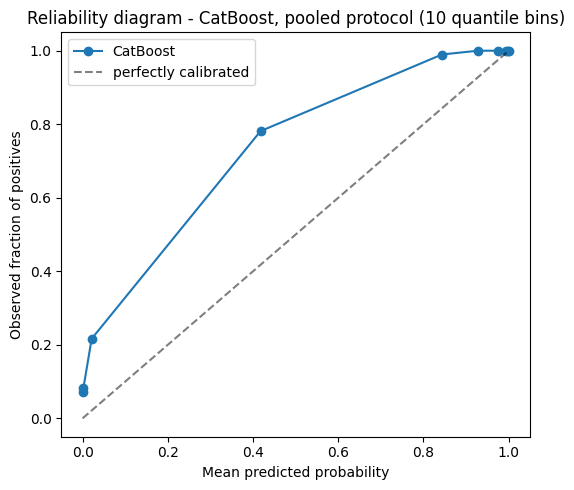

[A28] Calibration : {
 "n_bins": 10,
 "strategy": "quantile",
 "brier": 0.06891083861020779,
 "ece": 0.09665684235626604,
 "ece_uniform_bins_for_comparison": 0.09665684235626597,
 "caveat": "Brier and ECE are computed under the sampled, class-weighted distribution of the test partition; they do not establish calibration at registry prevalence"
}
[  11.9 min] Protocole B poole termine

[A2] AUC d'un classifieur n'utilisant que l'ecosysteme : 0.8036
   report as a descriptive property of the pooled sample. Do NOT write that a percentage of discrimination is 'attributable' to ecosystem identity: a ratio of two AUC-ROC differences is not a decomposition. Do NOT describe the pooled result as an upper bound or the transfer result as a lower bound.

[A1] ANALYSE PRIMAIRE NPM
npm: train 1223 / val 519 / test 763 | groupes 470/108/189
   proxies d'ecosysteme retires : 0 | espace candidat : 456
        initial -> 456
       variance -> 112
    mutual_info -> 100
         boruta -> 70
           

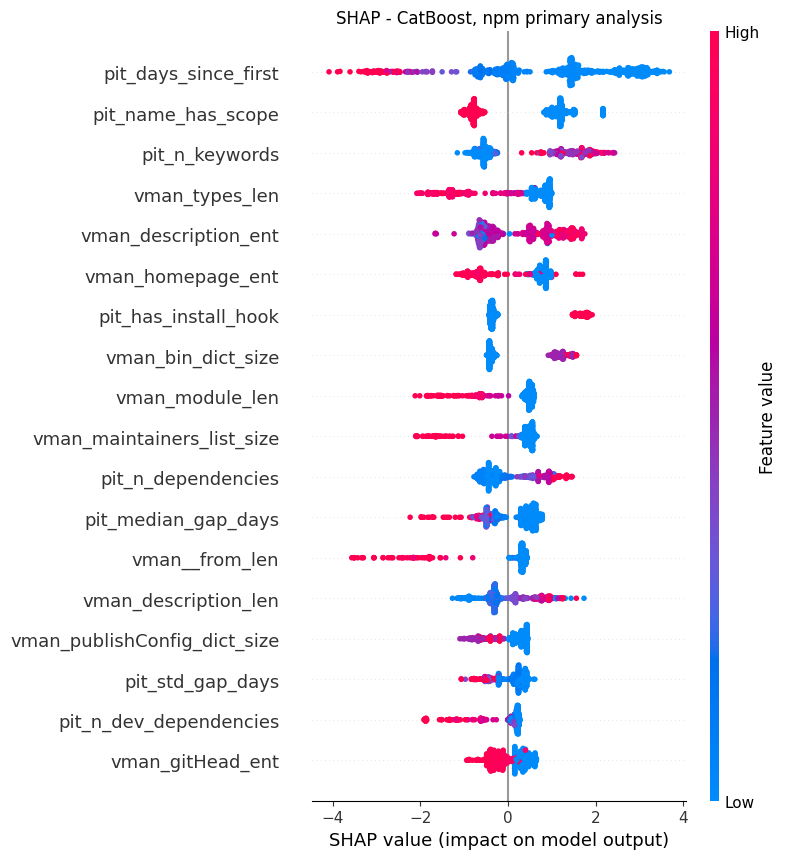

   SHAP top-6 : ['pit_days_since_first', 'pit_name_has_scope', 'pit_n_keywords', 'vman_types_len', 'vman_description_ent', 'vman_homepage_ent']
[  20.1 min] Analyse primaire NPM terminee

[A4] DECOMPOSITION INCREMENTALE
Versions hors test partageant un package avec le test : 0
Versions hors test partageant un groupe avec le test  : 0
-> le facteur GROUPEMENT ne peut pas etre isole a partition de test fixe :
   sur une partition group-aware il n'y a rien a faire fuir. D'ou deux blocs.
   G0 random stratified split (no grouping)                 acc=0.9844 au_pr=0.9967
   G1 grouping by package identity                          acc=0.9412 au_pr=0.9906
   G2 composite grouping (package+maintainer+name family)   acc=0.8915 au_pr=0.9919
   F0 selection on the full dataset + current-state attributes space=464 acc=0.9390 au_pr=0.9924
   F1 selection restricted to the training partition        space=464 acc=0.9277 au_pr=0.9913
   F2 + point-in-time attributes only                       space=45

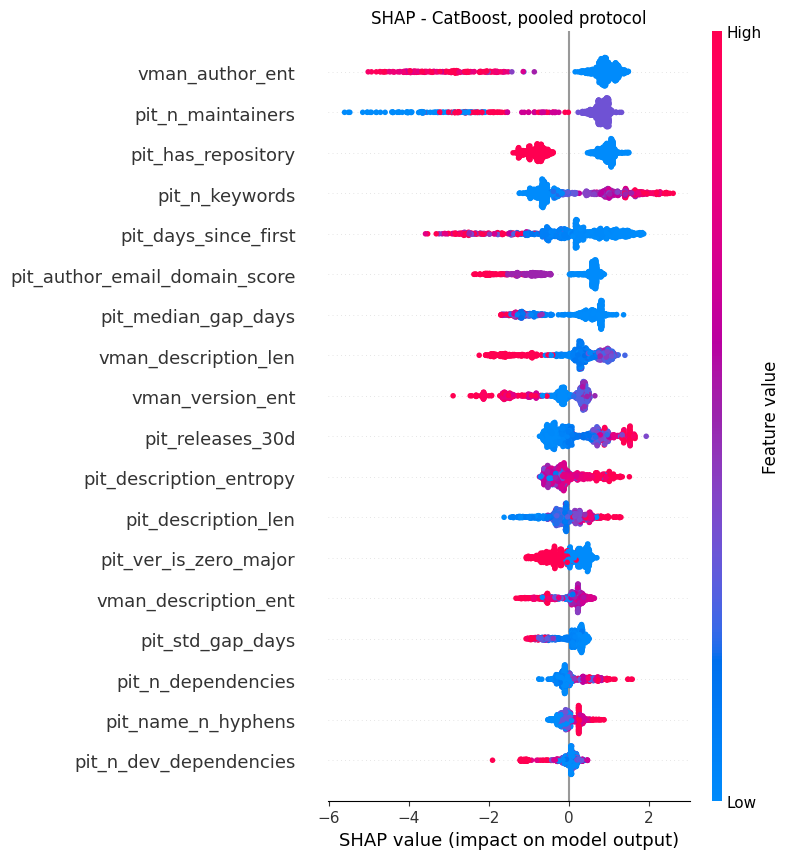

   200 tirages de stabilite : etape la plus longue du script (Boruta a chaque tirage). Reduire n_stability_runs si besoin.


selection stability:   0%|          | 0/200 [00:00<?, ?it/s]


[A21] 200 tirages | Jaccard moyen 0.709 | features retenues dans >=80% : 14/18 | stabilite des rangs SHAP 0.811 | accord SHAP/permutation 0.802
[ 144.5 min] SHAP et stabilite termines

[A20] ABLATIONS, ESTIMEES SUR LA VALIDATION
[A] Courbe cumulative :
   stage  k  val_auc_roc  val_au_pr  val_au_pr_baseline
 initial 40     0.992327   0.997166            0.721109
variance 40     0.992327   0.997166            0.721109
      mi 40     0.992327   0.997166            0.721109
  boruta 38     0.993129   0.997451            0.721109
     rfe 30     0.990296   0.996275            0.721109
    corr 26     0.990615   0.996435            0.721109
  budget 18     0.988325   0.995533            0.721109

[B] Leave-one-stage-out :
             removed  k  val_auc_roc  val_au_pr  val_au_pr_baseline  jaccard_with_full  delta_val_au_pr
none (full pipeline) 18     0.988325   0.995533            0.721109           1.000000         0.000000
            variance 18     0.988325   0.995533            0.72

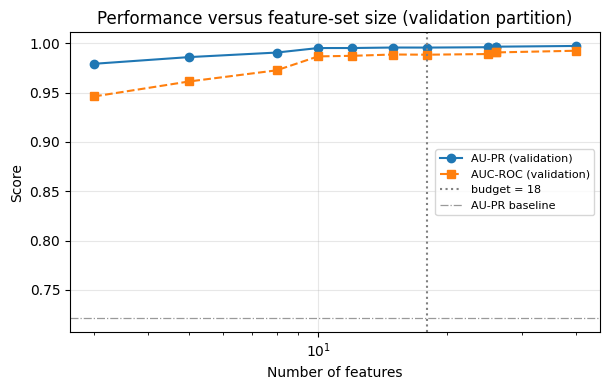


[H] Ablation par famille :
family_withheld  n_removed  k  val_auc_roc  val_au_pr  val_au_pr_baseline  delta_val_au_pr
       identity          2 16     0.980935   0.993034            0.721109        -0.002499
     authorship          3 15     0.983414   0.993375            0.721109        -0.002158
    description          5 13     0.982835   0.993933            0.721109        -0.001600
release_history          4 14     0.986117   0.994627            0.721109        -0.000906
   dependencies          2 16     0.988077   0.995161            0.721109        -0.000372
           none          0 18     0.988325   0.995533            0.721109         0.000000
     versioning          2 16     0.989800   0.996247            0.721109         0.000714
[ 168.2 min] Ablations terminees

CONFIGURATION VERROUILLEE, EVALUEE UNE FOIS SUR LE TEST
{
 "k": 18,
 "model": "CatBoost",
 "hyperparameters": {
  "iterations": 500,
  "learning_rate": 0.05,
  "depth": 6,
  "l2_leaf_reg": 1
 },
 "selected_on":

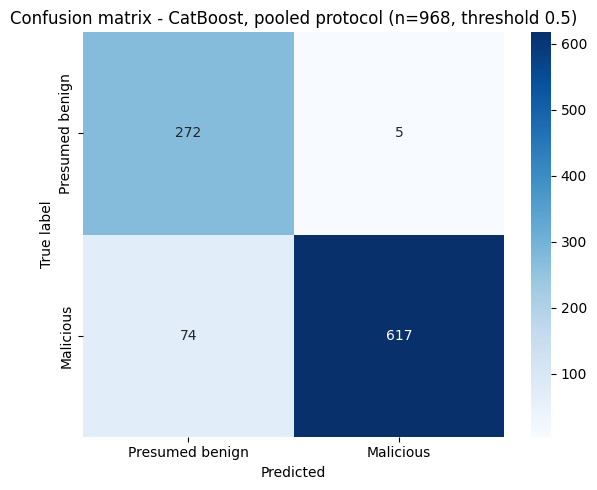


CORRESPONDANCE MANUSCRIT — REVISION 2       (169 min)
[A24] ENTONNOIR   464 inventaire
                  -> 456 point-in-time (moins 8 cur_)
                  -> 40 admissibles (exclusion a priori de 416 proxies, 91.2%)
                  -> 18 selectionnees (reduction PILOTEE PAR LES DONNEES : 55.0%)
   ecrire "40 -> 18 (55%)" et non "456 -> 18 (96%)" dans l'analyse poolee.

[A1] ANALYSE PRIMAIRE NPM   train 1223 / val 519 / test 763
   groupes 470/108/189 | espace candidat 456 (pre-filtre vide : 0)
   RandomForest : AUC-ROC 0.9828 | AU-PR 0.9972 (baseline 0.8755)
   matrice TN/FP/FN/TP = 92/3/24/644, n = 763

TABLE 5 (poole, secondaire)   CatBoost AUC-ROC 0.9762 | AU-PR 0.9918
   matrice TN/FP/FN/TP = 272/5/74/617, somme = 968

[A5] IC95 CLUSTER (CatBoost)    AUC-ROC [0.9508, 0.9903]  largeur 0.0394
                              AU-PR   [0.9771, 0.9972]  largeur 0.0201
   le bootstrap au niveau version donnait 0.0055 : facteur x3.66
   NE PLUS CITER 0.0055 nulle part.

[A8] GROUPES  

In [ ]:
# =============================================================================
# jcp-4466772 — PIPELINE COMPLET, REVISION 2
#
# Reprend la v7 et applique les correctifs exiges par les deux rapports du
# deuxieme tour. Chaque correctif est marque [Rx] et renvoie au grief.
#
#  [A1]  analyse primaire NPM (section dediee, protocole complet)
#  [A4]  decomposition incrementale de l'ecart A/B, en deux blocs
#  [A5]  IC par bootstrap PAR GRAPPES au niveau du group_id composite
#  [A6]  test apparie au niveau groupe (permutation de signe) au lieu de McNemar
#  [A7]  regle de trois sur les GROUPES benins independants
#  [A8]  comptes de groupes par partition / ecosysteme / classe
#  [A9]  meme group_id composite pour selection, tuning, stabilite, stacking
#  [A10] stacking group-aware documente (plis internes + entrees meta-apprenant)
#  [A11] transfert cross-ecosysteme SOURCE-ONLY (selection + reglage dans la source)
#  [A12] flux de collecte persiste dans collection_flow.json
#  [A16] AJUSTEMENT CANONIQUE UNIQUE -> supprime l'ecart Table 5 / Tables 7,9,10
#  [A20] budgets / ordres / familles / selecteurs estimes sur la VALIDATION
#  [A21] 200 reechantillonnages au lieu de 10
#  [A24] entonnoir 464 -> 456 -> 40 -> 18 rapporte comme deux operations
#  [A25] baselines aleatoires 18-de-40 ET 18-de-456, 200 tirages
#  [A26] procedure de seuil explicite, avec repli et prevalence declares
#  [A28] calibration : bins et strategie identiques pour la figure et l'ECE
#  [A30] appariement de maturite : caliper, remise, bris d'egalite, groupes
#  [A31] evasion par CHAMP SOURCE, features derivees recopiees conjointement
#  [A32] out-of-time : versions, groupes, benins, justification, IC
#  [A35] protocole de latence (repetitions, tailles de lot, IQR)
#
# ORDRE D'EXECUTION : une seule cellule. Duree indicative sur Colab, cache
# present : 60 a 120 minutes (Boruta et les grid searches dominent).
# =============================================================================

# --- 0. DEPENDANCES ---------------------------------------------------------
import subprocess, sys
def _pip(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
_pip(["pandas", "numpy", "requests", "tqdm", "scikit-learn", "catboost",
      "shap", "boruta", "scipy", "matplotlib", "seaborn"])

import os, re, json, time, random, shutil, warnings, itertools
import numpy as np, pandas as pd, requests
import matplotlib.pyplot as plt, seaborn as sns
from datetime import datetime, timezone
from collections import Counter
from tqdm.auto import tqdm
from sklearn.model_selection import (GroupShuffleSplit, train_test_split, GridSearchCV,
                                     StratifiedGroupKFold, cross_val_predict)
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             matthews_corrcoef, roc_auc_score, average_precision_score,
                             confusion_matrix, brier_score_loss)
from scipy.stats import binomtest, spearmanr, beta as _beta
from catboost import CatBoostClassifier
from boruta import BorutaPy
import shap

warnings.filterwarnings("ignore")
SEED = 42; random.seed(SEED); np.random.seed(SEED)
T0 = time.time()
def _t(msg): print(f"[{(time.time()-T0)/60:6.1f} min] {msg}", flush=True)

CFG = dict(
    targets={"npm": {1: 4500, 0: 4000}, "pypi": {1: 998, 0: 1000}},
    attempt_multiplier={"npm": 12, "pypi": 25},
    benign_attempt_multiplier=6,
    name_sim=0.85, test_frac=0.25, val_frac=0.20,
    var_thr=0.01, mi_topk=100, boruta_iter=50, boruta_alpha=0.05,
    rfe_target=30, rfe_step=5, corr_cut=0.85,
    n_boot=1000,                       # bootstrap naif, conserve pour comparaison
    n_cluster_boot=2000,               # [A5] bootstrap par grappes
    n_permutations=10000,              # [A6] test apparie au niveau groupe
    prevalences=[0.01, 0.001, 0.0001],
    alert_budget_10k=50, min_recall=0.80,
    operational_prevalence=0.001,      # [A26] declaree explicitement
    final_feature_budget=18,
    drop_single_ecosystem_features=True,
    budget_sweep=[3, 5, 8, 10, 12, 15, 18, 25, 30, 40],
    n_random_baseline=200,             # [A25] 20 -> 200
    n_stability_runs=200,              # [A21] 10 -> 200
    calibration_bins=10, calibration_strategy="quantile",   # [A28]
    match_caliper_days=90, match_caliper_releases=2,        # [A30]
    latency_repetitions=30, latency_batches=(1, 32, 256),   # [A35]
    n_rep_robustness=10,
    min_malicious_for_window=50, str_cap=200, size_cap=50,
    measure_latency=True,              # mettre a False si le reseau est bloque
    # -------------------------------------------------------------------------
    # [FIX 0.1] GARDE-FOU DE COLLECTE. Par defaut le script REFUSE de collecter.
    # Un run precedent a re-collecte silencieusement pendant 62 minutes parce que
    # les fichiers geles etaient absents, puis a ECRIT le nouveau jeu par-dessus
    # eux. Resultat : un jeu de 3 148 versions au lieu de 3 330, tous les chiffres
    # du manuscrit invalides, et le jeu original perdu.
    # Mettre a True UNIQUEMENT si vous voulez deliberement un nouveau jeu.
    allow_collection=False,
    expected_frozen_rows=3330,         # None pour desactiver la verification
    # -------------------------------------------------------------------------
)

try:
    from google.colab import drive; drive.mount('/content/drive')
    OUT = "/content/drive/MyDrive/JCP_revision"
except Exception:
    OUT = "./JCP_revision"
os.makedirs(OUT, exist_ok=True)
CACHE = f"{OUT}/dataset_v5.csv"
FLOW  = f"{OUT}/collection_flow.json"      # [A12]
R = {"config": {k: v for k, v in CFG.items()}}
_t(f"Sorties : {OUT}")

# =============================================================================
# 1. INTROSPECTION DU MANIFESTE (inchange)
# =============================================================================
MANIFEST_BLACKLIST = {"deprecated", "_npmUser", "_hasShrinkwrap", "_nodeVersion",
                      "_npmVersion", "_npmOperationalInternal", "yanked",
                      "yanked_reason", "downloads", "last_serial"}
LEAK_PATTERNS = ["exists", "error_type", "downloads", "last_serial", "yanked",
                 "deprecated", "status", "is_removed", "_npmUser"]

def _H(s):
    if not s: return 0.0
    n = len(s); return float(-sum((c/n)*np.log2(c/n) for c in Counter(s).values()))

def introspect(d, prefix):
    out = {}
    if not isinstance(d, dict): return out
    for k, v in d.items():
        if k in MANIFEST_BLACKLIST: continue
        key = re.sub(r"[^0-9a-zA-Z_]", "_", str(k))
        if isinstance(v, dict):
            out[f"{prefix}{key}_dict_size"] = min(len(v), CFG["size_cap"])
            out[f"{prefix}{key}_nested"] = int(any(isinstance(x, (dict, list)) for x in v.values()))
        elif isinstance(v, list):
            out[f"{prefix}{key}_list_size"] = min(len(v), CFG["size_cap"])
        elif isinstance(v, bool):
            out[f"{prefix}{key}_bool"] = int(v)
        elif isinstance(v, (int, float)):
            out[f"{prefix}{key}_num"] = float(max(min(v, 1e6), -1e6))
        elif isinstance(v, str):
            out[f"{prefix}{key}_len"] = min(len(v), CFG["str_cap"])
            out[f"{prefix}{key}_ent"] = _H(v[:CFG["str_cap"]])
    return out

def _ts(s):
    try: return datetime.fromisoformat(str(s).replace("Z","+00:00")).replace(tzinfo=timezone.utc)
    except Exception: return None

def _email_score(e):
    if not e or "@" not in str(e): return 0
    d = str(e).rsplit("@",1)[-1].lower()
    if d in {"mailinator.com","guerrillamail.com","10minutemail.com","tempmail.com","yopmail.com"}: return 3
    if d in {"gmail.com","yahoo.com","hotmail.com","outlook.com","qq.com","163.com","mail.ru"}: return 2
    return 1

def _vfeat(v):
    v = str(v or ""); nums = [int(x) for x in re.findall(r"\d+", v)]
    return {"pit_ver_len": len(v), "pit_ver_n_components": len(v.split(".")),
            "pit_ver_has_prerelease": int(bool(re.search(r"[-+]", v))),
            "pit_ver_is_zero_major": int(v.startswith("0.")),
            "pit_ver_is_initial": int(v in {"0.0.1","0.1.0","1.0.0","0.0.0"}),
            "pit_ver_max_component": max(nums or [0]), "pit_ver_entropy": _H(v)}

def _hist(all_ts, t_p):
    pr = sorted(t for t in all_ts if t and t < t_p)
    f = {"pit_n_prior_releases": len(pr)}
    if pr:
        f["pit_days_since_first"] = (t_p - pr[0]).total_seconds()/86400
        f["pit_days_since_prev"]  = (t_p - pr[-1]).total_seconds()/86400
        f["pit_releases_30d"]  = sum(1 for t in pr if (t_p - t).days <= 30)
        f["pit_releases_365d"] = sum(1 for t in pr if (t_p - t).days <= 365)
        g = np.diff([t.timestamp() for t in pr])/86400 if len(pr) > 1 else np.array([0.0])
        f["pit_median_gap_days"] = float(np.median(g)); f["pit_std_gap_days"] = float(np.std(g))
    else:
        f.update({"pit_days_since_first":0.0,"pit_days_since_prev":0.0,"pit_releases_30d":0,
                  "pit_releases_365d":0,"pit_median_gap_days":0.0,"pit_std_gap_days":0.0})
    return f

def _name(pkg):
    return {"pit_name_len": len(pkg), "pit_name_entropy": _H(pkg),
            "pit_name_has_scope": int(pkg.startswith("@")),
            "pit_name_n_hyphens": pkg.count("-"),
            "pit_name_n_digits": sum(c.isdigit() for c in pkg),
            "pit_name_n_dots": pkg.count(".")}

def npm_features(pkg, version=None, t_min=None, t_max=None):
    try: d = requests.get(f"https://registry.npmjs.org/{requests.utils.quote(pkg, safe='')}",
                          timeout=25).json()
    except Exception: return None
    if "error" in d or "versions" not in d: return None
    V, T = d.get("versions", {}), d.get("time", {})
    if version is None:
        c = [v for v in V if _ts(T.get(v))]
        if t_min is not None or t_max is not None:
            cw = [v for v in c if (t_min is None or _ts(T.get(v)) >= t_min)
                              and (t_max is None or _ts(T.get(v)) <= t_max)]
            c = cw or c
        if not c: return None
        version = random.Random(hash(pkg) ^ SEED).choice(c)
    if version not in V: return None
    t_p = _ts(T.get(version))
    if t_p is None: return None
    vd = V[version] or {}
    au = vd.get("author") or {}; au = {"email": au} if isinstance(au, str) else au
    mt = vd.get("maintainers") or []; sc = vd.get("scripts") or {}
    f = {"package": pkg, "version": version, "ecosystem": "npm", "t_p": t_p.isoformat(),
         "maintainer": (mt[0].get("name") or mt[0].get("email") or "")
                       if mt and isinstance(mt[0], dict) else ""}
    f.update(introspect(vd, "vman_"))
    f.update(_vfeat(version)); f.update(_hist([_ts(T.get(v)) for v in V], t_p)); f.update(_name(pkg))
    f.update({
        "pit_n_dependencies": len(vd.get("dependencies") or {}),
        "pit_n_dev_dependencies": len(vd.get("devDependencies") or {}),
        "pit_n_peer_dependencies": len(vd.get("peerDependencies") or {}),
        "pit_n_scripts": len(sc),
        "pit_has_install_hook": int(any(k in sc for k in ("preinstall","install","postinstall"))),
        "pit_scripts_total_len": sum(len(str(v)) for v in sc.values()),
        "pit_scripts_max_len": max([len(str(v)) for v in sc.values()] or [0]),
        "pit_description_len": len(vd.get("description") or ""),
        "pit_description_entropy": _H(vd.get("description") or ""),
        "pit_n_keywords": len(vd.get("keywords") or []),
        "pit_has_license": int(bool(vd.get("license"))),
        "pit_license_len": len(str(vd.get("license") or "")),
        "pit_has_repository": int(bool(vd.get("repository"))),
        "pit_has_homepage": int(bool(vd.get("homepage"))),
        "pit_has_bugs_url": int(bool(vd.get("bugs"))),
        "pit_n_maintainers": len(mt),
        "pit_author_email_domain_score": _email_score(au.get("email")),
        "pit_has_engines": int(bool(vd.get("engines"))),
        "pit_has_files_field": int(bool(vd.get("files"))),
        "pit_n_classifiers": 0, "pit_requires_python_len": 0, "pit_long_description_len": 0,
        "cur_n_versions_now": len(V), "cur_n_releases_now": len(T),
        "cur_n_maintainers_now": len(d.get("maintainers") or []),
        "cur_readme_len_now": len(str(d.get("readme") or "")),
        "cur_days_since_modified": ((datetime.now(timezone.utc) - _ts(T.get("modified"))).days
                                    if _ts(T.get("modified")) else 0),
        "cur_project_url_len_now": 0, "cur_description_len_now": 0, "cur_homepage_len_now": 0,
    })
    return f

def pypi_features(pkg, version=None, t_min=None, t_max=None):
    try: d = requests.get(f"https://pypi.org/pypi/{requests.utils.quote(pkg, safe='')}/json",
                          timeout=25).json()
    except Exception: return None
    rel = d.get("releases") or {}
    if not rel: return None
    def rts(v):
        fl = rel.get(v) or []
        return _ts(fl[0].get("upload_time_iso_8601")) if fl else None
    if version is None:
        c = [v for v in rel if rts(v)]
        if t_min is not None or t_max is not None:
            cw = [v for v in c if (t_min is None or rts(v) >= t_min)
                              and (t_max is None or rts(v) <= t_max)]
            c = cw or c
        if not c: return None
        version = random.Random(hash(pkg) ^ SEED).choice(c)
    t_p = rts(version)
    if t_p is None: return None
    try:
        dv = requests.get(f"https://pypi.org/pypi/{requests.utils.quote(pkg, safe='')}/"
                          f"{requests.utils.quote(str(version), safe='')}/json", timeout=25).json()
        info = dv.get("info") or {}
    except Exception:
        info = d.get("info") or {}
    reqs = info.get("requires_dist") or []
    kw = info.get("keywords") or ""; kw = kw.split(",") if isinstance(kw, str) else list(kw)
    f = {"package": pkg, "version": version, "ecosystem": "pypi", "t_p": t_p.isoformat(),
         "maintainer": info.get("author") or info.get("maintainer") or ""}
    f.update(introspect(info, "vman_"))
    f.update(_vfeat(version)); f.update(_hist([rts(v) for v in rel], t_p)); f.update(_name(pkg))
    f.update({
        "pit_n_dependencies": len(reqs),
        "pit_n_dev_dependencies": sum(1 for r in reqs if "extra ==" in str(r)),
        "pit_n_peer_dependencies": 0, "pit_n_scripts": 0, "pit_has_install_hook": 0,
        "pit_scripts_total_len": 0, "pit_scripts_max_len": 0,
        "pit_description_len": len(info.get("summary") or ""),
        "pit_description_entropy": _H(info.get("summary") or ""),
        "pit_long_description_len": len(info.get("description") or ""),
        "pit_n_keywords": len([k for k in kw if str(k).strip()]),
        "pit_has_license": int(bool(info.get("license"))),
        "pit_license_len": len(str(info.get("license") or "")),
        "pit_has_repository": int(bool(info.get("project_urls") or {})),
        "pit_has_homepage": int(bool(info.get("home_page"))),
        "pit_has_bugs_url": int("tracker" in json.dumps(info.get("project_urls") or {}).lower()),
        "pit_n_maintainers": int(bool(info.get("maintainer") or info.get("author"))),
        "pit_author_email_domain_score": _email_score(info.get("author_email")),
        "pit_has_engines": 0, "pit_has_files_field": 0,
        "pit_n_classifiers": len(info.get("classifiers") or []),
        "pit_requires_python_len": len(str(info.get("requires_python") or "")),
        "cur_n_versions_now": len(rel),
        "cur_n_releases_now": sum(len(v or []) for v in rel.values()),
        "cur_n_maintainers_now": int(bool((d.get("info") or {}).get("maintainer"))),
        "cur_readme_len_now": len((d.get("info") or {}).get("description") or ""),
        "cur_days_since_modified": 0,
        "cur_project_url_len_now": len(str((d.get("info") or {}).get("project_url") or "")),
        "cur_description_len_now": len((d.get("info") or {}).get("description") or ""),
        "cur_homepage_len_now": len(str((d.get("info") or {}).get("home_page") or "")),
    })
    return f

# =============================================================================
# 2. COLLECTE (avec persistance du flux, [A12])
# =============================================================================
BEHAVIOURS = ["exfiltrat","credential","token","steal","backdoor","reverse shell",
              "install hook","preinstall","postinstall","wallet","clipboard",
              "typosquat","dependency confusion","remote code","payload","miner"]
NPM_KW = ["utils","test","lib","api","cli","http","auth","parser","logger","config",
          "stream","crypto","date","format","validate","router","cache","queue","socket",
          "template","math","string","array","object","file","path","url","json","yaml",
          "csv","image","color","random","uuid","hash","compress","server","client",
          "proxy","middleware","plugin","build","bundle","lint","mock","fixture","assert",
          "benchmark","docs","types"]

def collect_malicious_versions(eco, limit):
    rows, seen, excl = [], set(), Counter()
    files = []
    for root, _, fs in os.walk(f"malicious-packages/osv/malicious/{eco}"):
        files += [os.path.join(root, f) for f in fs if f.endswith(".json")]
    excl["advisory_files_parsed"] = len(files)
    random.shuffle(files)
    for fp in tqdm(files, desc=f"OSV {eco}"):
        if len(rows) >= limit: break
        try: d = json.load(open(fp, encoding="utf-8"))
        except Exception: excl["json_unreadable"] += 1; continue
        if not any(b in json.dumps(d).lower() for b in BEHAVIOURS):
            excl["no_attributed_behaviour"] += 1; continue
        for a in d.get("affected", []):
            pk = a.get("package", {})
            if pk.get("ecosystem","").lower() != eco or not pk.get("name"): continue
            vs = a.get("versions") or []
            if not vs: excl["no_explicit_version"] += 1; continue
            for v in vs:
                if (pk["name"], v) in seen: excl["duplicate"] += 1; continue
                seen.add((pk["name"], v)); rows.append({"package": pk["name"], "version": v})
                if len(rows) >= limit: break
    excl["unique_package_version_pairs"] = len(rows)
    return pd.DataFrame(rows), dict(excl)

def collect_npm_benign_bulk(target):
    names = set()
    try:
        r = requests.get("https://raw.githubusercontent.com/nice-registry/"
                         "all-the-package-names/master/names.json", timeout=300)
        if r.status_code == 200: names.update(json.loads(r.text))
    except Exception as e:
        print("  liste globale NPM indisponible :", e)
    if not names:
        print("  repli sur l'API de recherche par mot-cle")
        return collect_npm_benign_search(target)
    names = sorted(names); random.Random(SEED).shuffle(names)
    print(f"  {len(names)} noms NPM disponibles")
    return names[: target * CFG["benign_attempt_multiplier"]]

def collect_npm_benign_search(limit):
    s = set()
    for t in tqdm(NPM_KW, desc="NPM search"):
        if len(s) >= limit * 4: break
        for start in range(0, 1000, 50):
            try:
                r = requests.get("https://registry.npmjs.org/-/v1/search",
                                 params={"text": t, "size": 50, "from": start}, timeout=20).json()
            except Exception: break
            o = r.get("objects", [])
            if not o: break
            s.update(x["package"]["name"] for x in o)
            if len(s) >= limit * 4: break
            time.sleep(0.15)
    return sorted(s)

def collect_pypi_benign(limit):
    s, excl = set(), Counter()
    try:
        r = requests.get("https://hugovk.github.io/top-pypi-packages/top-pypi-packages-30-days.json",
                         timeout=30).json()
        s.update(p["project"] for p in r.get("rows", [])[:1000])
    except Exception: excl["top_list_unreachable"] += 1
    try:
        allp = re.findall(r">([^<]+)</a>", requests.get("https://pypi.org/simple/", timeout=180).text)
        random.shuffle(allp); s.update(p.strip() for p in allp[:limit*4])
    except Exception: excl["simple_index_unreachable"] += 1
    return sorted(s), dict(excl)

def build(items, eco, label, target, desc, t_min=None, t_max=None):
    fn = npm_features if eco == "npm" else pypi_features
    out, seen, tried, failed = [], set(), 0, 0
    it = items if isinstance(items, list) else items.to_dict("records")
    bar = tqdm(it, desc=desc)
    for x in bar:
        if len(out) >= target: break
        pkg, ver = (x, None) if isinstance(x, str) else (x["package"], x.get("version"))
        if (pkg, ver) in seen: continue
        seen.add((pkg, ver)); tried += 1
        r_ = fn(pkg, ver, t_min, t_max)
        if r_: r_["label"] = label; out.append(r_)
        else:  failed += 1
        if tried % 200 == 0: bar.set_postfix(obtenus=len(out), cible=target)
    return pd.DataFrame(out), {"attempted": tried, "obtained": len(out),
                               "unretrievable_404_or_error": failed, "target": target,
                               "shortfall": max(0, target - len(out))}

# =============================================================================
# [FIX] SOURCE DE VERITE UNIQUE : le jeu gele du manuscrit.
# S'il existe, on le charge EXCLUSIVEMENT et on saute collecte + fenetrage +
# regroupement (deja figes dans ces deux fichiers). On ne le reecrit JAMAIS.
# =============================================================================
FROZEN_DATA = f"{OUT}/dataset_versions_point_in_time.csv"
FROZEN_PART = f"{OUT}/partition_assignment.csv"
USING_FROZEN = os.path.exists(FROZEN_DATA) and os.path.exists(FROZEN_PART)

# [FIX 0.1] Si le jeu gele est absent, on ARRETE plutot que de collecter en silence.
if not USING_FROZEN and not CFG["allow_collection"]:
    raise SystemExit(
        "\n" + "!"*74 + "\n"
        "ARRET : le jeu gele est introuvable et la collecte n'est pas autorisee.\n"
        f"  attendu : {FROZEN_DATA}\n"
        f"            {FROZEN_PART}\n"
        f"  present : {os.path.exists(FROZEN_DATA)} / {os.path.exists(FROZEN_PART)}\n\n"
        "Deux options :\n"
        "  1. RESTAURER (recommande) : recopiez les deux fichiers du manuscrit dans\n"
        f"     {OUT}/ puis relancez. Le premier message doit etre\n"
        "     '[FIX] Jeu GELE charge directement'.\n"
        "  2. COLLECTER un jeu NEUF : mettez CFG['allow_collection'] = True.\n"
        "     Attention : ~60 min, et TOUS les chiffres du manuscrit changeront\n"
        "     (une collecte ulterieure ne retrouve pas le meme echantillon).\n"
        + "!"*74)

if USING_FROZEN:
    df = pd.read_csv(FROZEN_DATA, low_memory=False)
    _part = pd.read_csv(FROZEN_PART)
    if CFG["expected_frozen_rows"] is not None:
        assert df.shape[0] == CFG["expected_frozen_rows"], (
            f"ATTENTION : {FROZEN_DATA} contient {df.shape[0]} lignes, pas "
            f"{CFG['expected_frozen_rows']}. Ce n'est PAS le fichier gele attendu. "
            f"Restaurez-le, ou mettez CFG['expected_frozen_rows'] = None si vous "
            f"travaillez deliberement sur un autre jeu.")
    df["t_p"] = pd.to_datetime(df["t_p"], utc=True, errors="coerce")
    _t(f"[FIX] Jeu GELE charge directement : {FROZEN_DATA}  ({df.shape}) "
       f"-> collecte, fenetrage temporel et regroupement SAUTES")
    R["collection"] = (json.load(open(FLOW)) if os.path.exists(FLOW)
                       else {"WARNING": "collection_flow.json absent"})
    R["collection"]["loaded_from_cache"] = True
    R["dataset"] = {"n_versions": int(len(df)), "n_packages": int(df.package.nunique()),
                    "n_groups": int(df.group_id.nunique()) if "group_id" in df.columns
                                else int(_part.group_id.nunique()),
                    "source": "frozen (dataset_versions_point_in_time.csv)"}
elif os.path.exists(CACHE):
    df = pd.read_csv(CACHE, low_memory=False)
    print("  !! " + "="*68)
    print(f"  !! ATTENTION : {FROZEN_DATA} absent. Chargement de {CACHE}.")
    print( "  !! CE N'EST PAS LE JEU DU MANUSCRIT. Ne publiez aucun chiffre de ce run")
    print( "  !! sans avoir verifie la provenance de ce cache.")
    print("  !! " + "="*68)
    _t(f"Jeu charge depuis le cache (NON GELE) : {CACHE}  ({df.shape})")
    if os.path.exists(FLOW):
        R["collection"] = json.load(open(FLOW)); R["collection"]["loaded_from_cache"] = True
    else:
        R["collection"] = {"loaded_from_cache": True, "WARNING": "collection_flow.json absent"}
else:
    for p in ["malicious-packages","malicious-packages-main","ossf.zip"]:
        if os.path.exists(p): shutil.rmtree(p) if os.path.isdir(p) else os.remove(p)
    subprocess.run(["wget","-q","https://github.com/ossf/malicious-packages/archive/"
                    "refs/heads/main.zip","-O","ossf.zip"], check=True)
    subprocess.run(["unzip","-q","ossf.zip"], check=True)
    os.rename("malicious-packages-main", "malicious-packages")
    TG, AM = CFG["targets"], CFG["attempt_multiplier"]
    npm_mal_df,  npm_excl  = collect_malicious_versions("npm",  TG["npm"][1]  * AM["npm"])
    pypi_mal_df, pypi_excl = collect_malicious_versions("pypi", TG["pypi"][1] * AM["pypi"])
    d1, s1 = build(npm_mal_df,  "npm",  1, TG["npm"][1],  "npm-mal")
    d2, s2 = build(pypi_mal_df, "pypi", 1, TG["pypi"][1], "pypi-mal")
    WIN = {}
    for dd, eco in [(d1, "npm"), (d2, "pypi")]:
        if len(dd) >= CFG["min_malicious_for_window"]:
            t = pd.to_datetime(dd["t_p"], utc=True, errors="coerce").dropna()
            WIN[eco] = (t.quantile(.05), t.quantile(.95))
        else: WIN[eco] = (None, None)
    npm_ben_names = collect_npm_benign_bulk(TG["npm"][0])
    pypi_ben_names, pypi_ben_excl = collect_pypi_benign(TG["pypi"][0])
    mal_names = set(npm_mal_df.package) | set(pypi_mal_df.package)
    n0 = (len(npm_ben_names), len(pypi_ben_names))
    npm_ben_names  = [p for p in npm_ben_names  if p not in mal_names]
    pypi_ben_names = [p for p in pypi_ben_names if p not in mal_names]
    d3, s3 = build(npm_ben_names,  "npm",  0, TG["npm"][0],  "npm-ben",
                   t_min=WIN["npm"][0],  t_max=WIN["npm"][1])
    d4, s4 = build(pypi_ben_names, "pypi", 0, TG["pypi"][0], "pypi-ben",
                   t_min=WIN["pypi"][0], t_max=WIN["pypi"][1])
    df = pd.concat([d1, d2, d3, d4], ignore_index=True)
    n_before_dedup = len(df)
    df = df.drop_duplicates(subset=["package","version","ecosystem"]).reset_index(drop=True)
    df.to_csv(CACHE, index=False)
    R["collection"] = {
        "yield": {"npm_malicious": s1, "pypi_malicious": s2,
                  "npm_benign": s3, "pypi_benign": s4},
        "osv_exclusions": {"npm": npm_excl, "pypi": pypi_excl},
        "pypi_benign_exclusions": pypi_ben_excl,
        "npm_benign_candidates_before_filter": n0[0],
        "pypi_benign_candidates_before_filter": n0[1],
        "rows_before_final_dedup": int(n_before_dedup),
        "rows_after_final_dedup": int(len(df)),
        "benign_version_selection_rule":
            ("one version drawn uniformly at random with a package-specific seed "
             "(random.Random(hash(pkg) ^ SEED)) among the versions published within the "
             "temporal window of that ecosystem"),
        "temporal_windows_from_malicious": {
            k: [str(v[0]), str(v[1])] if v[0] is not None else None for k, v in WIN.items()},
        "npm_keywords": NPM_KW, "behaviour_terms": BEHAVIOURS, "loaded_from_cache": False}
    json.dump(R["collection"], open(FLOW, "w"), indent=2, default=str)   # [A12]
    _t("Flux de collecte persiste dans collection_flow.json")

df["t_p"] = pd.to_datetime(df["t_p"], utc=True, errors="coerce")
df = df.dropna(subset=["t_p"]).reset_index(drop=True).fillna(0)
_t(f"Dimensions apres nettoyage : {df.shape}")

META = ["package","version","ecosystem","t_p","maintainer","label","group_id","canon"]
allfeat = [c for c in df.columns if c not in META]
inv = pd.DataFrame({"feature": allfeat,
                    "family": ["vman (version manifest)" if c.startswith("vman_")
                               else "pit (reconstructed at t_p)" if c.startswith("pit_")
                               else "cur (current registry state)" if c.startswith("cur_")
                               else "other" for c in allfeat],
                    "point_in_time": [not c.startswith("cur_") for c in allfeat],
                    "n_unique": [int(df[c].nunique()) for c in allfeat]})
inv.to_csv(f"{OUT}/feature_inventory.csv", index=False)
R["feature_space"] = {"total": len(allfeat),
                      "vman": int(sum(c.startswith("vman_") for c in allfeat)),
                      "pit": int(sum(c.startswith("pit_") for c in allfeat)),
                      "cur": int(sum(c.startswith("cur_") for c in allfeat))}
_t(f"Espace de features : {R['feature_space']}")

# =============================================================================
# 3. FENETRE TEMPORELLE + GROUPES COMPOSITES
# [FIX] SAUTE si le jeu gele est la source : group_id/canon et le fenetrage
# temporel y sont deja figes dedans. Les refaire donnerait un group_id
# DIFFERENT de celui de partition_assignment.csv, et romprait la
# correspondance entre les deux fichiers geles.
# =============================================================================
canon = lambda s: re.sub(r"[^a-z0-9]", "", str(s).lower())

def nsim(a, b):
    """[A33] SIMILARITE normalisee = 1 - d(a,b)/max(|a|,|b|), d = Levenshtein.
    Deux noms sont regroupes si nsim >= 0.85, soit distance normalisee <= 0.15."""
    if a == b: return 1.0
    la, lb = len(a), len(b)
    if not la or not lb: return 0.0
    prev = list(range(lb+1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j]+1, cur[j-1]+1, prev[j-1]+(ca != cb)))
        prev = cur
    return 1.0 - prev[lb]/max(la, lb)

class UF:
    def __init__(s): s.p = {}
    def find(s, x):
        s.p.setdefault(x, x)
        while s.p[x] != x: s.p[x] = s.p[s.p[x]]; x = s.p[x]
        return x
    def union(s, a, b):
        ra, rb = s.find(a), s.find(b)
        if ra != rb: s.p[ra] = rb

def window_and_group(df):
    """Fenetrage temporel par ecosysteme puis regroupement composite
    (package + mainteneur + famille de noms). Retourne (df, win, npairs)."""
    parts, win = [], {}
    for eco in df.ecosystem.unique():
        sub = df[df.ecosystem == eco]; mal = sub[sub.label == 1]
        if len(mal) < CFG["min_malicious_for_window"]:
            parts.append(sub); win[eco] = "none (too few malicious)"; continue
        lo_e, hi_e = mal.t_p.quantile(.05), mal.t_p.quantile(.95)
        parts.append(sub[(sub.t_p >= lo_e) & (sub.t_p <= hi_e)])
        win[eco] = [str(lo_e.date()), str(hi_e.date())]
    nb0 = len(df); df = pd.concat(parts, ignore_index=True)
    _t(f"Fenetrage temporel : {nb0} -> {len(df)} versions | {win}")

    uf = UF(); df["canon"] = df["package"].map(canon)
    for _, r_ in df.iterrows():
        uf.find(("pkg", r_["canon"]))
        m = str(r_.get("maintainer") or "").strip().lower()
        if m and m not in ("nan", "0"): uf.union(("pkg", r_["canon"]), ("mnt", m))
    blocks = {}
    for n in sorted(df["canon"].unique()): blocks.setdefault((n[:2], len(n)//4), []).append(n)
    npairs = 0
    for blk in tqdm(blocks.values(), desc="name families"):
        for a, b in itertools.combinations(blk, 2):
            if abs(len(a)-len(b)) <= 3 and nsim(a, b) >= CFG["name_sim"]:
                uf.union(("pkg", a), ("pkg", b)); npairs += 1
    df["group_id"] = df["canon"].map(lambda n: str(uf.find(("pkg", n))))
    return df, win, npairs

if USING_FROZEN:
    win = {"npm": "frozen (already windowed in dataset_versions_point_in_time.csv)",
           "pypi": "frozen (already windowed in dataset_versions_point_in_time.csv)"}
    npairs = None
    sz = df.group_id.value_counts()
    _t(f"[FIX] group_id/canon geles reutilises tels quels : {len(df)} versions | "
       f"{df.package.nunique()} packages | {df.group_id.nunique()} groupes | "
       f"plus grand {sz.iloc[0]} ({sz.iloc[0]/len(df):.1%})")
else:
    df, win, npairs = window_and_group(df)
    sz = df.group_id.value_counts()
    _t(f"{len(df)} versions | {df.package.nunique()} packages | {df.group_id.nunique()} groupes "
       f"| plus grand {sz.iloc[0]} ({sz.iloc[0]/len(df):.1%})")

R["dataset"] = {"n_versions": int(len(df)), "n_packages": int(df.package.nunique()),
                "n_groups": int(df.group_id.nunique()), "largest_group": int(sz.iloc[0]),
                "similar_name_pairs": npairs, "windows": win,
                "name_similarity_rule": "1 - levenshtein/max(len) >= %.2f" % CFG["name_sim"],
                "composition": {f"{e}_{l}": int(n)
                                for (e,l), n in df.groupby(["ecosystem","label"]).size().items()}}

# =============================================================================
# 4. FONCTIONS COMMUNES
# =============================================================================
def eco_proxy_features(part, prefixes, active=None):
    active = CFG["drop_single_ecosystem_features"] if active is None else active
    if not active or part.ecosystem.nunique() < 2: return []
    X = part.drop(columns=[c for c in META if c in part.columns], errors="ignore")
    X = X.select_dtypes(include=[np.number])
    cols = [c for c in X.columns if c.startswith(prefixes)]
    return [c for c in cols if (part.groupby("ecosystem")[c].std().fillna(0) == 0).any()]

ECO_PROXIES = []

def fframe(part, prefixes, eco_proxies=None):
    ep = set(ECO_PROXIES if eco_proxies is None else eco_proxies)
    X = part.drop(columns=[c for c in META if c in part.columns], errors="ignore")
    X = X.select_dtypes(include=[np.number])
    keep = [c for c in X.columns if c.startswith(prefixes)
            and not any(re.search(p, c) for p in LEAK_PATTERNS) and c not in ep]
    return X[keep].copy()

def make_prep(train_part, prefixes, eco_proxies=None):
    """[A18] Un SEUL chemin de pretraitement : imputation mediane -> winsorisation
    1/99 -> standardisation, ajuste sur le TRAIN et applique tel quel ailleurs.
    Les trois classifieurs recoivent la meme matrice."""
    X0 = fframe(train_part, prefixes, eco_proxies); F0 = list(X0.columns)
    imp = SimpleImputer(strategy="median").fit(X0[F0])
    A = imp.transform(X0[F0])
    LOq, HIq = np.nanpercentile(A, 1, 0), np.nanpercentile(A, 99, 0)
    scl = StandardScaler().fit(np.clip(A, LOq, HIq))
    def prep(part):
        X = fframe(part, prefixes, eco_proxies).reindex(columns=F0, fill_value=0)
        return pd.DataFrame(scl.transform(np.clip(imp.transform(X), LOq, HIq)),
                            columns=F0, index=part.index)
    return prep, F0

def select(X, y, stages=("variance","mi","boruta","rfe","corr","budget"),
           budget=None, verbose=True):
    log, cur = {"initial": X.shape[1]}, list(X.columns)
    B = CFG["final_feature_budget"] if budget is None else budget
    def say(k, v):
        log[k] = len(v)
        if verbose: print(f"   {k:>12} -> {len(v)}")
    if verbose: print(f"   {'initial':>12} -> {len(cur)}")
    for st in stages:
        if st == "variance":
            s = VarianceThreshold(CFG["var_thr"]).fit(X[cur])
            cur = [c for c, k in zip(cur, s.get_support()) if k]; say("variance", cur)
        elif st == "mi":
            mi = mutual_info_classif(X[cur], y, random_state=SEED)
            cur = [cur[i] for i in sorted(np.argsort(mi)[::-1][:CFG["mi_topk"]])]; say("mutual_info", cur)
        elif st == "boruta":
            b = BorutaPy(RandomForestClassifier(n_jobs=-1, max_depth=5, random_state=SEED,
                         class_weight="balanced"), n_estimators="auto", verbose=0,
                         random_state=SEED, max_iter=CFG["boruta_iter"], alpha=CFG["boruta_alpha"])
            b.fit(X[cur].values, y)
            k = [c for c, s_ in zip(cur, b.support_) if s_]; cur = k or cur; say("boruta", cur)
        elif st == "rfe":
            k = min(CFG["rfe_target"], len(cur))
            r_ = RFE(CatBoostClassifier(iterations=100, learning_rate=0.1, depth=4, verbose=0,
                     random_state=SEED, thread_count=1),
                     n_features_to_select=k, step=CFG["rfe_step"]).fit(X[cur], y)
            cur = [c for c, s_ in zip(cur, r_.support_) if s_]; say("rfe", cur)
        elif st == "corr":
            mi = dict(zip(cur, mutual_info_classif(X[cur], y, random_state=SEED)))
            C = X[cur].corr().abs(); keep, drop = [], set()
            for f_ in sorted(cur, key=lambda z: -mi[z]):
                if f_ in drop: continue
                keep.append(f_)
                for o in C.index[C[f_] > CFG["corr_cut"]]:
                    if o != f_ and o not in keep: drop.add(o)
            cur = keep; say("corr_prune", cur)
        elif st == "budget":
            if B and len(cur) > B:
                m_ = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, verbose=0,
                                        random_state=SEED, thread_count=1,
                                        auto_class_weights="Balanced").fit(X[cur], y)
                imp_ = pd.Series(m_.get_feature_importance(), index=cur).sort_values(ascending=False)
                cur = list(imp_.head(B).index); say("budget", cur)
    return [str(c) for c in cur], log

def metrics(y, s, thr=0.5):
    yp = (np.asarray(s) >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yp, labels=[0,1]).ravel()
    assert tn+fp+fn+tp == len(y)
    p  = precision_score(y, yp, pos_label=1, zero_division=0)
    r_ = recall_score(y, yp, pos_label=1, zero_division=0)
    return dict(n=int(len(y)), TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp),
                accuracy=accuracy_score(y, yp), precision=p, recall=r_,
                f1=f1_score(y, yp, pos_label=1, zero_division=0),
                mcc=matthews_corrcoef(y, yp),
                auc_roc=roc_auc_score(y, s), au_pr=average_precision_score(y, s),
                au_pr_baseline=float(np.mean(y)),
                specificity=tn/(tn+fp) if tn+fp else np.nan,
                fpr=fp/(tn+fp) if tn+fp else np.nan,
                brier=float(brier_score_loss(y, s)), threshold=float(thr))

def fpr_upper(fp, n_ben, conf=0.95):
    if n_ben <= 0:  return np.nan
    if fp <= 0:     return 3.0 / n_ben
    if fp >= n_ben: return 1.0
    return float(_beta.ppf(conf, fp + 1, n_ben - fp))

# ---- [A5] bootstrap PAR GRAPPES -------------------------------------------
def cluster_boot_ci(y, s, g, fn, n=None):
    n = CFG["n_cluster_boot"] if n is None else n
    rng = np.random.default_rng(SEED)
    y, s, g = np.asarray(y), np.asarray(s), np.asarray(g)
    uq = np.unique(g); by = {u: np.where(g == u)[0] for u in uq}
    v = []
    for _ in range(n):
        idx = np.concatenate([by[u] for u in rng.choice(uq, size=len(uq), replace=True)])
        if len(np.unique(y[idx])) > 1: v.append(fn(y[idx], s[idx]))
    return {"point": float(fn(y, s)),
            "ci95": [float(np.percentile(v,2.5)), float(np.percentile(v,97.5))],
            "width": float(np.percentile(v,97.5) - np.percentile(v,2.5)),
            "n_groups": int(len(uq)), "n_valid_draws": int(len(v))}

def naive_boot_ci(y, s, fn, n=None):
    n = CFG["n_boot"] if n is None else n
    rng = np.random.default_rng(SEED); y, s = np.asarray(y), np.asarray(s); v = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) > 1: v.append(fn(y[i], s[i]))
    return {"point": float(fn(y, s)),
            "ci95": [float(np.percentile(v,2.5)), float(np.percentile(v,97.5))],
            "width": float(np.percentile(v,97.5) - np.percentile(v,2.5))}

# ---- [A6] test apparie au niveau GROUPE ------------------------------------
def grouped_paired_test(y, sa, sb, g, thr=0.5, n_perm=None):
    n_perm = CFG["n_permutations"] if n_perm is None else n_perm
    y = np.asarray(y)
    ok_a = (((np.asarray(sa) >= thr).astype(int)) == y).astype(float)
    ok_b = (((np.asarray(sb) >= thr).astype(int)) == y).astype(float)
    d = pd.DataFrame({"g": np.asarray(g), "d": ok_a - ok_b}).groupby("g")["d"].mean()
    obs = float(d.mean()); rng = np.random.default_rng(SEED)
    cnt = sum(abs(float((d.values * rng.choice([-1,1], len(d))).mean())) >= abs(obs)
              for _ in range(n_perm))
    return {"mean_group_delta_accuracy": obs, "n_groups": int(len(d)),
            "p_permutation": float((cnt+1)/(n_perm+1))}

# ---- [A26] seuil operationnel, regle explicite -----------------------------
def choose_threshold(y_val, s_val, min_recall=None, budget=None, prevalence=None):
    """Contrainte 1 : rappel >= min_recall. Contrainte 2 : <= budget alertes/10 000,
    calculees a la prevalence operationnelle declaree. REPLI si la contrainte 2 est
    inatteignable : minimiser les alertes/10 000 parmi les seuils satisfaisant la
    contrainte 1. REPLI ULTIME si aucun seuil n'atteint min_recall : seuil de rappel
    maximal."""
    min_recall = CFG["min_recall"] if min_recall is None else min_recall
    budget     = CFG["alert_budget_10k"] if budget is None else budget
    prevalence = CFG["operational_prevalence"] if prevalence is None else prevalence
    s_val = np.asarray(s_val); cands, allc = [], []
    for t in np.unique(np.round(s_val, 3)):
        yp = (s_val >= t).astype(int)
        rec = recall_score(y_val, yp, pos_label=1, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_val, yp, labels=[0,1]).ravel()
        f_ = fpr_upper(fp, fp+tn)
        alerts = 10000*(rec*prevalence + f_*(1-prevalence))
        if not np.isfinite(alerts): continue
        rec_ = (float(t), float(rec), float(alerts), int(fp), int(fp+tn))
        allc.append(rec_)
        if rec >= min_recall: cands.append(rec_)
    rule = {"constraint_1": f"recall >= {min_recall}",
            "constraint_2": f"<= {budget} alerts per 10,000 screened",
            "assumed_operational_prevalence": prevalence,
            "fallback": ("minimise alerts/10k among thresholds satisfying constraint 1; "
                         "if none satisfies constraint 1, take the maximum-recall threshold")}
    if not cands:
        b = max(allc, key=lambda z: z[1])
        return b[0], False, {**rule, "outcome": "no threshold reaches the recall constraint",
                             "value": b[0], "recall": b[1], "alerts_per_10k": b[2]}
    feas = [c for c in cands if c[2] <= budget]
    if feas:
        b = max(feas, key=lambda z: z[1])
        return b[0], True, {**rule, "outcome": "both constraints satisfied",
                            "value": b[0], "recall": b[1], "alerts_per_10k": b[2]}
    b = min(cands, key=lambda z: z[2])
    return b[0], False, {**rule, "outcome": "alert budget unattainable; fallback applied",
                         "value": b[0], "recall": b[1], "alerts_per_10k": b[2],
                         "false_positives": f"{b[3]}/{b[4]}"}

def prev_table_group(y, s, thr, n_ben_groups, n_flagged_groups, pv=None):
    """[A7] Table de prevalence dont la borne de faux positifs porte sur les GROUPES
    benins independants, et non sur les versions. C'est ce que demande le relecteur :
    'the false-positive bound should account for the number and sizes of independent
    benign groups'.

    [FIX 0.3] La version precedente melangeait les unites : elle passait a fpr_upper()
    un NUMERATEUR compte en versions (fp de la matrice de confusion) et un DENOMINATEUR
    compte en groupes. Les deux sont desormais au niveau groupe. Le TPR reste au niveau
    version : c'est la quantite operationnelle (une version malveillante manquee est un
    incident), alors que le cout des faux positifs se paie par alerte investiguee, et
    des versions du meme groupe donnent une seule investigation."""
    pv = CFG["prevalences"] if pv is None else pv
    tn, fp, fn, tp = confusion_matrix(y, (np.asarray(s) >= thr).astype(int),
                                      labels=[0,1]).ravel()
    tpr = tp/(tp+fn) if tp+fn else np.nan
    assert 0 <= n_flagged_groups <= n_ben_groups, (
        f"incoherence : {n_flagged_groups} groupes signales sur {n_ben_groups} benins")
    fprG = fpr_upper(n_flagged_groups, n_ben_groups)   # 3/n si 0 signale (regle de trois)
    rows = []
    for pi in pv:
        den = tpr*pi + fprG*(1-pi)
        rows.append({"prevalence": pi, "fpr_estimate": "upper95_group_level",
                     "TPR_version_level": tpr, "FPR_group_level": fprG,
                     "n_benign_groups": int(n_ben_groups),
                     "n_flagged_groups": int(n_flagged_groups),
                     "PPV": (tpr*pi)/den if den > 0 else np.nan,
                     "alerts_per_10k": 10000*den,
                     "true_positives_per_10k": 10000*tpr*pi,
                     "missed_per_10k": 10000*pi*(1-tpr)})
    return pd.DataFrame(rows)

def prev_table(y, s, thr, pv=None):
    pv = CFG["prevalences"] if pv is None else pv
    tn, fp, fn, tp = confusion_matrix(y, (np.asarray(s) >= thr).astype(int), labels=[0,1]).ravel()
    tpr = tp/(tp+fn) if tp+fn else np.nan
    fpr = fp/(fp+tn) if fp+tn else np.nan
    fprU = fpr_upper(fp, fp+tn)
    rows = []
    for pi in pv:
        for lab, f_ in [("point", fpr), ("upper95", fprU)]:
            den = tpr*pi + f_*(1-pi)
            rows.append({"prevalence": pi, "fpr_estimate": lab, "TPR": tpr, "FPR": f_,
                         "PPV": (tpr*pi)/den if den and den > 0 else np.nan,
                         "alerts_per_10k": 10000*den if den == den else np.nan,
                         "true_positives_per_10k": 10000*tpr*pi,
                         "missed_per_10k": 10000*pi*(1-tpr)})
    return pd.DataFrame(rows)

# ---- [A28] ECE avec la MEME strategie de bins que la figure ----------------
def ece(y, s, bins=None, strategy=None):
    bins = CFG["calibration_bins"] if bins is None else bins
    strategy = CFG["calibration_strategy"] if strategy is None else strategy
    y, s = np.asarray(y), np.asarray(s)
    edges = (np.unique(np.quantile(s, np.linspace(0,1,bins+1))) if strategy == "quantile"
             else np.linspace(0,1,bins+1))
    e, n = 0.0, len(y)
    for i in range(len(edges)-1):
        m_ = ((s >= edges[i]) if i == 0 else (s > edges[i])) & (s <= edges[i+1])
        if m_.sum() == 0: continue
        e += (m_.sum()/n) * abs(y[m_].mean() - s[m_].mean())
    return float(e)

def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b)/len(a | b) if (a | b) else np.nan

# ---- [A16] AJUSTEMENT CANONIQUE : un seul point d'instanciation ------------
DEFAULT_HP = {"CatBoost": {"iterations": 500, "learning_rate": 0.1, "depth": 6, "l2_leaf_reg": 3},
              "RandomForest": {"n_estimators": 200, "max_depth": 20,
                               "min_samples_split": 5, "max_features": "sqrt"}}
HP_CANON = {"CatBoost": dict(DEFAULT_HP["CatBoost"]),
            "RandomForest": dict(DEFAULT_HP["RandomForest"])}

def canon_cat(hp=None):
    p = dict(HP_CANON["CatBoost"]); p.update(hp or {})
    return CatBoostClassifier(verbose=0, random_state=SEED, thread_count=1,
                              auto_class_weights="Balanced", **p)

def canon_rf(hp=None):
    p = dict(HP_CANON["RandomForest"]); p.update(hp or {})
    return RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1, **p)

class GroupAwareStacking:
    """[A10] Meta-apprenant logistique sur les probabilites OUT-OF-FOLD de CatBoost et
    Random Forest. Les plis internes sont des StratifiedGroupKFold(5) construits sur le
    MEME group_id composite que la partition externe : aucun package, mainteneur ou
    famille de noms ne peut se trouver a la fois dans le pli d'ajustement d'une base et
    dans le pli qui alimente le meta-apprenant. cv=5 ordinaire ne garantissait pas cela."""
    def __init__(self, hp=None, n_splits=5, seed=SEED):
        self.hp = hp or {}; self.n_splits = n_splits; self.seed = seed
    def fit(self, X, y, groups):
        cv = StratifiedGroupKFold(n_splits=self.n_splits, shuffle=True, random_state=self.seed)
        oof = np.column_stack([
            cross_val_predict(canon_cat(self.hp.get("CatBoost")), X, y, cv=cv,
                              groups=groups, method="predict_proba")[:, 1],
            cross_val_predict(canon_rf(self.hp.get("RandomForest")), X, y, cv=cv,
                              groups=groups, method="predict_proba")[:, 1]])
        self.meta_ = LogisticRegression(C=1.0, penalty="l2", max_iter=1000).fit(oof, y)
        self.bases_ = {"cat": canon_cat(self.hp.get("CatBoost")).fit(X, y),
                       "rf":  canon_rf(self.hp.get("RandomForest")).fit(X, y)}
        self.oof_ = oof
        return self
    def predict_proba(self, X):
        Z = np.column_stack([self.bases_["cat"].predict_proba(X)[:, 1],
                             self.bases_["rf"].predict_proba(X)[:, 1]])
        return self.meta_.predict_proba(Z)
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

def build_models(hp=None):
    hp = hp or {}
    return {"CatBoost": canon_cat(hp.get("CatBoost")),
            "RandomForest": canon_rf(hp.get("RandomForest")),
            "Stacking": GroupAwareStacking(hp)}

def fit_all(models, Xtr, ytr, groups):
    out = {}
    for nm, m in models.items():
        if isinstance(m, GroupAwareStacking): m.fit(Xtr, ytr, groups=groups)
        else: m.fit(Xtr, ytr)
        out[nm] = m
    return out

GRIDS = {"CatBoost": {"depth": [4, 6, 8], "learning_rate": [0.01, 0.05, 0.1],
                      "l2_leaf_reg": [1, 3, 5], "iterations": [500]},
         "RandomForest": {"n_estimators": [100, 200, 300], "max_depth": [10, 20, None],
                          "min_samples_split": [2, 5, 10], "max_features": ["sqrt", "log2"]}}

def tune(X, y, groups, tag=""):
    """[A9] Grid search en StratifiedGroupKFold sur le MEME group_id composite.
    [A17] Score optimise : average_precision (AU-PR), metrique primaire."""
    cv = StratifiedGroupKFold(5, shuffle=True, random_state=SEED)
    hp, info = {}, {}
    for nm, grid in GRIDS.items():
        est = canon_cat() if nm == "CatBoost" else canon_rf()
        gs = GridSearchCV(est, grid, scoring="average_precision", cv=cv, n_jobs=-1)
        gs.fit(X, y, groups=groups)
        hp[nm] = gs.best_params_
        info[nm] = {"grid": grid, "selected": gs.best_params_,
                    "cv_score_au_pr": float(gs.best_score_),
                    "cv": "StratifiedGroupKFold(5) on composite group_id"}
        print(f"   {tag}{nm:14s} -> {gs.best_params_}  (CV AU-PR {gs.best_score_:.4f})")
    return hp, info

# =============================================================================
# 5. PROTOCOLE A — reproduction du protocole soumis (analyse de reference)
# =============================================================================
print("\n" + "="*74 + "\nPROTOCOLE A (reproduction de la soumission initiale)\n" + "="*74)
ECO_PROXIES = []
prepA, F0A = make_prep(df, ("vman_","pit_","cur_"))
XA = prepA(df); yA = df.label.values
SEL_A, LOG_A = select(XA, yA)
iA_tr, iA_te = train_test_split(np.arange(len(df)), test_size=CFG["test_frac"],
                                stratify=yA, random_state=SEED)
rowsA = []
for nm, m in build_models().items():
    if isinstance(m, GroupAwareStacking):
        m.fit(XA.iloc[iA_tr][SEL_A], yA[iA_tr], groups=df.iloc[iA_tr].group_id.values)
    else:
        m.fit(XA.iloc[iA_tr][SEL_A], yA[iA_tr])
    s = m.predict_proba(XA.iloc[iA_te][SEL_A])[:,1]
    rowsA.append({"protocol":"A_original","model":nm, **metrics(yA[iA_te], s)})
TA = pd.DataFrame(rowsA)
print(TA[["model","accuracy","auc_roc","au_pr","TN","FP","FN","TP"]].to_string(index=False))
R["protocol_A"] = {"selection_log": LOG_A, "selected": SEL_A, "table": TA.to_dict("records")}
_t("Protocole A termine")

# =============================================================================
# 6. PROTOCOLE B POOLE — analyse SECONDAIRE [A1]
# =============================================================================
print("\n" + "="*74 + "\nPROTOCOLE B POOLE (analyse secondaire)\n" + "="*74)
# [FIX] Partition : si le jeu gele est la source, on REUTILISE la partition
# gelee (partition_assignment.csv) au lieu de la recalculer. Cela garantit que
# le test contient exactement les 968 versions / 373 groupes du manuscrit,
# quelle que soit la version de scikit-learn.
if USING_FROZEN:
    _key = ["package", "version", "ecosystem"]
    _m = df.merge(_part[_key + ["split"]], on=_key, how="left")
    _m.index = df.index
    assert _m.split.notna().all(), (
        "partition_assignment.csv ne couvre pas toutes les lignes du jeu gele")
    train = df[_m.split.values == "train"].copy()
    val   = df[_m.split.values == "val"].copy()
    test  = df[_m.split.values == "test"].copy()
    _t(f"[FIX] Partition GELEE reutilisee : train {len(train)} / val {len(val)} / "
       f"test {len(test)} | groupes {train.group_id.nunique()}/"
       f"{val.group_id.nunique()}/{test.group_id.nunique()}")
else:
    i_tv, i_te = next(GroupShuffleSplit(1, test_size=CFG["test_frac"], random_state=SEED)
                      .split(df, df.label, groups=df.group_id))
    trval, test = df.iloc[i_tv].copy(), df.iloc[i_te].copy()
    i_tr, i_va = next(GroupShuffleSplit(1, test_size=CFG["val_frac"], random_state=SEED)
                      .split(trval, trval.label, groups=trval.group_id))
    train, val = trval.iloc[i_tr].copy(), trval.iloc[i_va].copy()
for a, b, nm in [(train,val,"tr/va"), (train,test,"tr/te"), (val,test,"va/te")]:
    assert not (set(a.group_id) & set(b.group_id)), f"fuite de groupe {nm}"

ECO_PROXIES = eco_proxy_features(train, ("vman_","pit_"))
prepB, F0B = make_prep(train, ("vman_","pit_"))
Xtr, Xva, Xte = prepB(train), prepB(val), prepB(test)
y_tr, y_va, y_te = train.label.values, val.label.values, test.label.values
g_tr, g_va, g_te = train.group_id.values, val.group_id.values, test.group_id.values
print("Selection (train uniquement) :")
SEL_B, LOG_B = select(Xtr, y_tr)
Xtr_s, Xva_s, Xte_s = Xtr[SEL_B], Xva[SEL_B], Xte[SEL_B]

# ---- [A24] ENTONNOIR DE FEATURES : deux operations distinctes --------------
_, F_pit_full = make_prep(train, ("vman_","pit_"), eco_proxies=[])
FUNNEL = {"inventory_total": R["feature_space"]["total"],
          "current_state_excluded": R["feature_space"]["cur"],
          "point_in_time_candidates": len(F_pit_full),
          "ecosystem_proxies_removed_a_priori": len(ECO_PROXIES),
          "admissible_after_prefilter": len(F0B),
          "selected_data_driven": len(SEL_B),
          "a_priori_reduction_pct": round(100*(1-len(F0B)/len(F_pit_full)), 1),
          "data_driven_reduction_pct": round(100*(1-len(SEL_B)/len(F0B)), 1),
          "note": ("the ecosystem-proxy pre-filter is an a priori exclusion of attributes "
                   "constant within one ecosystem; the data-driven reduction is "
                   "admissible -> selected, not point_in_time -> selected")}
print("\n[A24] Entonnoir :", json.dumps(FUNNEL, indent=2))
R["feature_funnel"] = FUNNEL

print("\nGrid search (CV groupee sur le group_id composite) :")
HP, HP_INFO = tune(Xtr_s, y_tr, g_tr, tag="pooled ")
R["hyperparameters"] = HP_INFO
# [A16] a partir d'ici, canon_cat()/canon_rf() utilisent les HP retenus
HP_CANON["CatBoost"].update(HP["CatBoost"])
HP_CANON["RandomForest"].update(HP["RandomForest"])
json.dump(HP_CANON, open(f"{OUT}/hyperparameters.json", "w"), indent=2)
R["canonical_fit"] = {**HP_CANON, "thread_count": 1, "seed": SEED,
    "meta_learner": {"LogisticRegression": {"C": 1.0, "penalty": "l2", "max_iter": 1000}},
    "class_weights": {"CatBoost": "auto_class_weights=Balanced",
                      "RandomForest": "class_weight=balanced"},
    "optimisation_score": "average_precision",
    "note": ("single canonical fit used in every table; the previous version fitted the "
             "ablation tables with CatBoost defaults (learning_rate=0.1, l2_leaf_reg=3), "
             "which is the entire cause of the Table 5 / Table 7 discrepancy")}
print("[A16] Ajustement canonique :", json.dumps(HP_CANON, indent=1))

fitB = fit_all(build_models(), Xtr_s, y_tr, g_tr)
scoB = {nm: {"test": m.predict_proba(Xte_s)[:,1], "val": m.predict_proba(Xva_s)[:,1]}
        for nm, m in fitB.items()}
TB = pd.DataFrame([{"protocol":"B_pooled","model":nm, **metrics(y_te, scoB[nm]["test"])}
                   for nm in fitB])
print("\n", TB[["model","accuracy","precision","recall","f1","mcc","auc_roc","au_pr",
                "au_pr_baseline","specificity","fpr","TN","FP","FN","TP"]].to_string(index=False))
BEST = TB.sort_values("au_pr", ascending=False).iloc[0]["model"]; mbest = fitB[BEST]
R["stacking_procedure"] = {
    "n_inner_folds": 5, "inner_cv": "StratifiedGroupKFold on composite group_id",
    "meta_inputs": "out-of-fold P(malicious) of CatBoost and RandomForest",
    "meta_learner": "LogisticRegression(C=1.0, l2, max_iter=1000)",
    "meta_coefficients": fitB["Stacking"].meta_.coef_[0].tolist(),
    "meta_intercept": float(fitB["Stacking"].meta_.intercept_[0])}

# ---- [A5][A6] inference au niveau groupe ----------------------------------
print("\n[A5] Bootstrap par grappes vs bootstrap naif :")
CI = {}
for nm in fitB:
    CI[nm] = {}
    for k, fn in [("auc_roc", roc_auc_score), ("au_pr", average_precision_score)]:
        c = cluster_boot_ci(y_te, scoB[nm]["test"], g_te, fn)
        n_ = naive_boot_ci(y_te, scoB[nm]["test"], fn)
        CI[nm][k] = {"cluster": c, "naive_version_level": n_,
                     "width_ratio": c["width"]/n_["width"]}
        print(f"   {nm:13s} {k:8s} cluster [{c['ci95'][0]:.4f},{c['ci95'][1]:.4f}] "
              f"w={c['width']:.4f} | naif w={n_['width']:.4f} -> x{c['width']/n_['width']:.2f}")
R["cluster_bootstrap"] = CI
CI_W = CI[BEST]["au_pr"]["cluster"]["width"]
print(f"   Largeur de reference (cluster, AU-PR, {BEST}) : {CI_W:.4f}")

print("\n[A6] Test apparie au niveau groupe (remplace McNemar) :")
PAIRED, MCN = {}, {}
for a, b in itertools.combinations(fitB, 2):
    PAIRED[f"{a}_vs_{b}"] = grouped_paired_test(y_te, scoB[a]["test"], scoB[b]["test"], g_te)
    pa = (scoB[a]["test"] >= .5).astype(int); pb_ = (scoB[b]["test"] >= .5).astype(int)
    B_ = int(np.sum((pa==y_te) & (pb_!=y_te))); C_ = int(np.sum((pa!=y_te) & (pb_==y_te)))
    MCN[f"{a}_vs_{b}"] = {"b": B_, "c": C_,
        "p_exact": float(binomtest(min(B_,C_), B_+C_, .5).pvalue) if B_+C_ else 1.0}
nb = max(len(PAIRED), 1)
for k in PAIRED: PAIRED[k]["p_bonferroni"] = min(1.0, PAIRED[k]["p_permutation"]*nb)
for k in MCN:    MCN[k]["p_bonferroni"]    = min(1.0, MCN[k]["p_exact"]*nb)
print(json.dumps(PAIRED, indent=1))
print("   McNemar non groupe, conserve pour comparaison :", json.dumps(MCN, indent=1))
R["grouped_paired_tests"] = PAIRED; R["mcnemar_ungrouped_for_comparison"] = MCN

# ---- [A8] comptes de groupes ----------------------------------------------
GC = (df.groupby(["ecosystem","label"]).agg(versions=("package","size"),
      packages=("package","nunique"), groups=("group_id","nunique")))
splitmap = pd.concat([p.assign(split=n) for p, n in
                      [(train,"train"), (val,"val"), (test,"test")]])
GC2 = (splitmap.groupby(["split","ecosystem","label"])
       .agg(versions=("package","size"), packages=("package","nunique"),
            groups=("group_id","nunique")).reset_index())
GC2["label"] = GC2["label"].map({0: "presumed_benign", 1: "malicious"})
print("\n[A8] Groupes par partition / ecosysteme / classe :")
print(GC2.to_string(index=False))
GC2.to_csv(f"{OUT}/tableS_group_counts.csv", index=False)
R["group_counts"] = {
    "by_split_ecosystem_class": GC2.to_dict("records"),
    "n_groups_total": int(df.group_id.nunique()),
    "n_groups_train": int(train.group_id.nunique()),
    "n_groups_val": int(val.group_id.nunique()),
    "n_groups_test": int(test.group_id.nunique()),
    "largest_group_overall": int(sz.iloc[0]),
    "largest_group_in_test": int(test.group_id.value_counts().iloc[0]),
    "largest_group_share_of_test": float(test.group_id.value_counts().iloc[0]/len(test))}

# ---- [A26][A7] seuil, prevalence, regle de trois sur les GROUPES ----------
thr, feasible, THR_INFO = choose_threshold(y_va, scoB[BEST]["val"])
mthr = metrics(y_te, scoB[BEST]["test"], thr)
PT = prev_table(y_te, scoB[BEST]["test"], thr)
_m0 = (y_te == 0)
_bg = test.loc[_m0, "group_id"]
_fpg = test.loc[_m0 & (scoB[BEST]["test"] >= thr), "group_id"].nunique()
RULE3 = {"n_benign_versions": int(_m0.sum()), "n_benign_groups": int(_bg.nunique()),
         "n_benign_groups_flagged": int(_fpg),
         "largest_benign_group": int(_bg.value_counts().iloc[0]),
         "median_benign_group_size": float(_bg.value_counts().median()),
         "upper95_group_fpr": float(fpr_upper(_fpg, _bg.nunique())),
         "bound_rule": ("rule of three (3/n) when no group is flagged, otherwise the "
                        "one-sided 95% Clopper-Pearson upper bound; numerator AND "
                        "denominator both counted in GROUPS"),
         "note": "rule of three over INDEPENDENT BENIGN GROUPS, not benign versions"}
print(f"\n[A26] Seuil operationnel : {thr:.3f}")
print(json.dumps(THR_INFO, indent=1))
print(f"   au seuil : rappel {mthr['recall']:.3f}, FP {mthr['FP']}/{mthr['FP']+mthr['TN']}")
print("[A7] Regle de trois au niveau groupe :", json.dumps(RULE3, indent=1))
THR_INFO["threshold_used_in_table5"] = 0.5
THR_INFO["validation_recall"] = float(recall_score(y_va, (scoB[BEST]["val"] >= thr).astype(int),
                                                   pos_label=1, zero_division=0))
THR_INFO["test_recall"] = float(mthr["recall"])
# [A7] Table de prevalence au niveau GROUPE : c'est celle a publier.
PTG = prev_table_group(y_te, scoB[BEST]["test"], thr,
                       RULE3["n_benign_groups"], RULE3["n_benign_groups_flagged"])
print("\n[A7] Table de prevalence, borne au niveau GROUPE (a publier) :")
print(PTG.to_string(index=False))
PTG.to_csv(f"{OUT}/table12_operational_prevalence_group_level.csv", index=False)
R["operational_threshold"] = {**THR_INFO, "rule_of_three_group_level": RULE3,
                              "metrics_at_threshold": mthr,
                              "prevalence_table_version_level": PT.to_dict("records"),
                              "prevalence_table_group_level": PTG.to_dict("records"),
                              "note_on_prevalence_table": (
                                  "publish the GROUP-level table: the version-level bound "
                                  "(3/n_benign_versions) treats correlated versions as "
                                  "independent trials")}

# ---- [A28] calibration, meme binning pour la figure et l'ECE --------------
s_best = scoB[BEST]["test"]
frac, mean_pred = calibration_curve(y_te, s_best, n_bins=CFG["calibration_bins"],
                                    strategy=CFG["calibration_strategy"])
plt.figure(figsize=(5.5, 5))
plt.plot(mean_pred, frac, "o-", label=BEST)
plt.plot([0,1], [0,1], "k--", alpha=.5, label="perfectly calibrated")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed fraction of positives")
plt.title(f"Reliability diagram - {BEST}, pooled protocol "
          f"({CFG['calibration_bins']} {CFG['calibration_strategy']} bins)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUT}/figure06_calibration.png", dpi=300); plt.show()
CAL = {"n_bins": CFG["calibration_bins"], "strategy": CFG["calibration_strategy"],
       "brier": float(brier_score_loss(y_te, s_best)),
       "ece": ece(y_te, s_best),
       "ece_uniform_bins_for_comparison": ece(y_te, s_best, strategy="uniform"),
       "curve": [{"mean_predicted": float(a), "observed_fraction": float(b)}
                 for a, b in zip(mean_pred, frac)],
       "caveat": ("Brier and ECE are computed under the sampled, class-weighted "
                  "distribution of the test partition; they do not establish calibration "
                  "at registry prevalence")}
print("[A28] Calibration :", json.dumps({k: v for k, v in CAL.items() if k != "curve"}, indent=1))
R["calibration"] = CAL
pd.DataFrame(CAL["curve"]).to_csv(f"{OUT}/figure06_calibration_data.csv", index=False)

R["protocol_B_pooled"] = {"selection_log": LOG_B, "selected": SEL_B,
    "table": TB.to_dict("records"), "best_model": BEST,
    "split": {"n_train": len(train), "n_val": len(val), "n_test": len(test),
              "test_malicious": int(test.label.sum()),
              "test_presumed_benign": int((1-test.label).sum())}}
TB.to_csv(f"{OUT}/table05_model_performance.csv", index=False)
_t("Protocole B poole termine")

# ---- confondant d'ecosysteme, sans le langage causal [A2][A3] --------------
auc_eco = roc_auc_score(df.label.values,
                        df.ecosystem.map(df.groupby("ecosystem")["label"].mean()).values)
ratios = df.groupby("ecosystem")["label"].agg(["mean","size"])
R["ecosystem_confound"] = {
    "auc_ecosystem_only": float(auc_eco),
    "auc_model_pooled": float(TB.set_index("model").loc[BEST,"auc_roc"]),
    "malicious_rate_by_ecosystem": ratios["mean"].to_dict(),
    "n_by_ecosystem": ratios["size"].to_dict(),
    "reporting_note": ("report as a descriptive property of the pooled sample. Do NOT "
                       "write that a percentage of discrimination is 'attributable' to "
                       "ecosystem identity: a ratio of two AUC-ROC differences is not a "
                       "decomposition. Do NOT describe the pooled result as an upper "
                       "bound or the transfer result as a lower bound.")}
print(f"\n[A2] AUC d'un classifieur n'utilisant que l'ecosysteme : {auc_eco:.4f}")
print("   " + R["ecosystem_confound"]["reporting_note"])

# =============================================================================
# 7. [A1] ANALYSE PRIMAIRE NPM
# =============================================================================
print("\n" + "="*74 + "\n[A1] ANALYSE PRIMAIRE NPM\n" + "="*74)
def run_primary(sub, tag):
    tr_, va_, te_ = (sub[sub.index.isin(train.index)], sub[sub.index.isin(val.index)],
                     sub[sub.index.isin(test.index)])
    print(f"{tag}: train {len(tr_)} / val {len(va_)} / test {len(te_)} | groupes "
          f"{tr_.group_id.nunique()}/{va_.group_id.nunique()}/{te_.group_id.nunique()}")
    eco = eco_proxy_features(tr_, ("vman_","pit_"))
    prep_, F_ = make_prep(tr_, ("vman_","pit_"), eco_proxies=eco)
    print(f"   proxies d'ecosysteme retires : {len(eco)} | espace candidat : {len(F_)}")
    Xa, Xb, Xc = prep_(tr_), prep_(va_), prep_(te_)
    ya, yb, yc = tr_.label.values, va_.label.values, te_.label.values
    SEL_, LOG_ = select(Xa, ya)
    hp_, info_ = tune(Xa[SEL_], ya, tr_.group_id.values, tag=f"{tag} ")
    save = {k: dict(v) for k, v in HP_CANON.items()}
    HP_CANON["CatBoost"].update(hp_["CatBoost"]); HP_CANON["RandomForest"].update(hp_["RandomForest"])
    fits = fit_all(build_models(), Xa[SEL_], ya, tr_.group_id.values)
    sc = {nm: {"test": m.predict_proba(Xc[SEL_])[:,1], "val": m.predict_proba(Xb[SEL_])[:,1]}
          for nm, m in fits.items()}
    T_ = pd.DataFrame([{"model": nm, **metrics(yc, sc[nm]["test"])} for nm in fits])
    print(T_[["model","accuracy","auc_roc","au_pr","au_pr_baseline",
              "TN","FP","FN","TP","n"]].to_string(index=False))
    best_ = T_.sort_values("au_pr", ascending=False).iloc[0]["model"]
    gc_ = te_.group_id.values
    ci_ = {nm: {"auc_roc": cluster_boot_ci(yc, sc[nm]["test"], gc_, roc_auc_score),
                "au_pr":   cluster_boot_ci(yc, sc[nm]["test"], gc_, average_precision_score)}
           for nm in sc}
    thr_, feas_, ti_ = choose_threshold(yb, sc[best_]["val"])
    m0_ = yc == 0
    bg_ = te_.loc[m0_, "group_id"]
    fpg_ = te_.loc[m0_ & (sc[best_]["test"] >= thr_), "group_id"].nunique()
    # SHAP sur l'analyse primaire
    try:
        sv_ = shap.TreeExplainer(canon_cat().fit(Xa[SEL_], ya)).shap_values(Xc[SEL_])
        if isinstance(sv_, list): sv_ = sv_[1]
        shap.summary_plot(sv_, Xc[SEL_], show=False)
        plt.title(f"SHAP - CatBoost, {tag} primary analysis"); plt.tight_layout()
        plt.savefig(f"{OUT}/figure05_shap_{tag}.png", dpi=300, bbox_inches="tight"); plt.show()
        shp = (pd.DataFrame({"feature": SEL_, "mean_abs_shap": np.abs(sv_).mean(0)})
               .sort_values("mean_abs_shap", ascending=False))
        shp.to_csv(f"{OUT}/shap_{tag}.csv", index=False)
        print("   SHAP top-6 :", list(shp.feature.head(6)))
        shp_rec = shp.to_dict("records")
    except Exception as e:
        print("   SHAP indisponible :", e); shp_rec = []
    out = {"tag": tag,
        "split": {"n_train": len(tr_), "n_val": len(va_), "n_test": len(te_),
                  "groups_train": int(tr_.group_id.nunique()),
                  "groups_val": int(va_.group_id.nunique()),
                  "groups_test": int(te_.group_id.nunique()),
                  "test_malicious": int(yc.sum()), "test_presumed_benign": int((1-yc).sum())},
        "candidate_space": len(F_), "ecosystem_proxies_removed": len(eco),
        "note_on_prefilter": ("single ecosystem: eco_proxy_features returns an empty list "
                              "by construction, so the candidate space is the full "
                              "point-in-time space and the reduction IS data-driven"),
        "selection_log": LOG_, "selected": SEL_, "hyperparameters": info_,
        "table": T_.to_dict("records"), "best_model": best_, "cluster_ci95": ci_,
        "threshold": {**ti_, "metrics_at_threshold": metrics(yc, sc[best_]["test"], thr_)},
        "rule_of_three_group_level": {
            "n_benign_versions": int(m0_.sum()), "n_benign_groups": int(bg_.nunique()),
            "n_benign_groups_flagged": int(fpg_),
            "upper95_group_fpr": float(fpr_upper(fpg_, bg_.nunique()))},
        "prevalence_table_version_level": prev_table(yc, sc[best_]["test"], thr_
                                                     ).to_dict("records"),
        "prevalence_table_group_level": prev_table_group(
            yc, sc[best_]["test"], thr_, bg_.nunique(), fpg_).to_dict("records"),
        "shap_ranking": shp_rec}
    T_.to_csv(f"{OUT}/table05_model_performance_{tag}.csv", index=False)
    HP_CANON["CatBoost"] = save["CatBoost"]; HP_CANON["RandomForest"] = save["RandomForest"]
    return out

R["primary_npm"] = run_primary(df[df.ecosystem == "npm"], "npm")
_t("Analyse primaire NPM terminee")

# =============================================================================
# 8. [A4] DECOMPOSITION INCREMENTALE DE L'ECART A/B
# =============================================================================
print("\n" + "="*74 + "\n[A4] DECOMPOSITION INCREMENTALE\n" + "="*74)
pool_out = df[~df.index.isin(test.index)]
shared_pkg = int(pool_out.package.isin(set(test.package)).sum())
shared_grp = int(pool_out.group_id.isin(set(test.group_id)).sum())
print(f"Versions hors test partageant un package avec le test : {shared_pkg}")
print(f"Versions hors test partageant un groupe avec le test  : {shared_grp}")
print("-> le facteur GROUPEMENT ne peut pas etre isole a partition de test fixe :\n"
      "   sur une partition group-aware il n'y a rien a faire fuir. D'ou deux blocs.")

# --- Bloc 1 : le facteur groupement, par repartitionnement controle --------
dfr = df.reset_index(drop=True)
def sp_naive():
    i1, i2 = train_test_split(np.arange(len(dfr)), test_size=CFG["test_frac"],
                              stratify=dfr.label, random_state=SEED)
    return dfr.iloc[i1], dfr.iloc[i2]
def sp_by(col):
    i1, i2 = next(GroupShuffleSplit(1, test_size=CFG["test_frac"], random_state=SEED)
                  .split(dfr, dfr.label, groups=dfr[col]))
    return dfr.iloc[i1], dfr.iloc[i2]
rows = []
for name, mk in [("G0 random stratified split (no grouping)", sp_naive),
                 ("G1 grouping by package identity", lambda: sp_by('package')),
                 ("G2 composite grouping (package+maintainer+name family)",
                  lambda: sp_by('group_id'))]:
    t_, e_ = mk()
    p_, F_ = make_prep(t_, ("vman_","pit_","cur_"), eco_proxies=[])
    S_, _ = select(p_(t_), t_.label.values, verbose=False)
    s_ = canon_cat().fit(p_(t_)[S_], t_.label.values).predict_proba(p_(e_)[S_])[:,1]
    rows.append({"config": name, "n_candidates": len(F_), "k": len(S_),
                 "n_train": len(t_), "n_test": len(e_),
                 "train_versions_sharing_package_with_test":
                     int(t_.package.isin(set(e_.package)).sum()),
                 **{k: v for k, v in metrics(e_.label.values, s_).items()
                    if k in ("accuracy","auc_roc","au_pr","au_pr_baseline")}})
    print(f"   {name:56s} acc={rows[-1]['accuracy']:.4f} au_pr={rows[-1]['au_pr']:.4f}")
D1 = pd.DataFrame(rows); D1["delta_accuracy_vs_previous"] = D1.accuracy.diff()
D1.to_csv(f"{OUT}/tableS_leakage_block1_grouping.csv", index=False)

# --- Bloc 2 : partition composite gelee, un facteur par ligne --------------
N_TR = len(train)
def tr_comp():
    c = pool_out[~pool_out.group_id.isin(set(test.group_id))]
    return c.sample(n=min(N_TR, len(c)), random_state=SEED)
LADDER = [("F0 selection on the full dataset + current-state attributes", "all",
           ("vman_","pit_","cur_"), False),
          ("F1 selection restricted to the training partition", "train",
           ("vman_","pit_","cur_"), False),
          ("F2 + point-in-time attributes only", "train", ("vman_","pit_"), False),
          ("F3 + ecosystem proxies removed (= pooled protocol B)", "train",
           ("vman_","pit_"), True)]
rows = []
for name, scope, pref, drop_eco in LADDER:
    t_ = tr_comp()
    eco_ = eco_proxy_features(t_, pref) if drop_eco else []
    p_, F_ = make_prep(t_, pref, eco_proxies=eco_)
    if scope == "all":
        pa_, _ = make_prep(df, pref, eco_proxies=eco_)
        S_, _ = select(pa_(df), df.label.values, verbose=False)
    else:
        S_, _ = select(p_(t_), t_.label.values, verbose=False)
    S_ = [f for f in S_ if f in F_]
    s_ = canon_cat().fit(p_(t_)[S_], t_.label.values).predict_proba(p_(test)[S_])[:,1]
    rows.append({"config": name, "n_candidates": len(F_), "k": len(S_),
                 **{k: v for k, v in metrics(y_te, s_).items()
                    if k in ("accuracy","auc_roc","au_pr","au_pr_baseline")}})
    print(f"   {name:56s} space={len(F_):3d} acc={rows[-1]['accuracy']:.4f} "
          f"au_pr={rows[-1]['au_pr']:.4f}")
D2 = pd.DataFrame(rows); D2["delta_accuracy_vs_previous"] = D2.accuracy.diff()
D2.to_csv(f"{OUT}/tableS_leakage_block2_fixed_test.csv", index=False)
print("\nBloc 1 (groupement) :"); print(D1[["config","accuracy","delta_accuracy_vs_previous","au_pr"]].to_string(index=False))
print("\nBloc 2 (test fige) :");  print(D2[["config","accuracy","delta_accuracy_vs_previous","au_pr"]].to_string(index=False))
delta_AB = (TA.set_index("model")["accuracy"] - TB.set_index("model")["accuracy"])
print(f"\nEcart agrege A - B (accuracy) : {delta_AB.round(4).to_dict()} | "
      f"moyenne {delta_AB.mean():.4f} -> {100*delta_AB.mean():.1f} points")
R["leakage_decomposition"] = {
    "aggregate_A_minus_B_accuracy": delta_AB.round(6).to_dict(),
    "aggregate_A_minus_B_accuracy_mean": float(delta_AB.mean()),
    "aggregate_A_minus_B_accuracy_points": round(100*float(delta_AB.mean()), 1),
    "block1_grouping": D1.to_dict("records"),
    "block2_fixed_test_partition": D2.to_dict("records"),
    "no_leakage_injectable_at_fixed_test": {"shared_packages": shared_pkg,
                                            "shared_groups": shared_grp,
                                            "pool_size": int(len(pool_out))},
    "caveat": ("the two blocks rest on different bases and their deltas are NOT additive; "
               "no additive decomposition of the aggregate difference is claimed. Describe "
               "the 5.9-point figure as the aggregate difference between two evaluation "
               "protocols, and report each factor with its own controlled comparison.")}
_t("Decomposition terminee")

# =============================================================================
# 9. [A11] TRANSFERT CROSS-ECOSYSTEME SOURCE-ONLY
# =============================================================================
print("\n" + "="*74 + "\n[A11] TRANSFERT SOURCE-ONLY\n" + "="*74)
TRANSFER = {}
for a, b in [("npm","pypi"), ("pypi","npm")]:
    A_, B_ = df[df.ecosystem==a], df[df.ecosystem==b]
    if not (len(A_) and len(B_) and A_.label.nunique()>1 and B_.label.nunique()>1): continue
    p_, F_ = make_prep(A_, ("vman_","pit_"), eco_proxies=[])   # mono-ecosysteme
    XA_, yA_, gA_ = p_(A_), A_.label.values, A_.group_id.values
    SEL_s, LOG_s = select(XA_, yA_, verbose=False)
    cv = StratifiedGroupKFold(5, shuffle=True, random_state=SEED)
    gs = GridSearchCV(canon_cat(), {"depth":[4,6],"learning_rate":[0.05,0.1],
                                    "l2_leaf_reg":[1,3],"iterations":[500]},
                      scoring="average_precision", cv=cv, n_jobs=-1)
    gs.fit(XA_[SEL_s], yA_, groups=gA_)
    m_ = canon_cat(gs.best_params_).fit(XA_[SEL_s], yA_)
    XB_, yB_ = p_(B_), B_.label.values
    s_ = m_.predict_proba(XB_[SEL_s])[:,1]
    TRANSFER[f"{a}->{b}"] = {
        "n_source": len(A_), "n_target": len(B_),
        "groups_source": int(A_.group_id.nunique()), "groups_target": int(B_.group_id.nunique()),
        "target_malicious": int(yB_.sum()), "candidate_space": len(F_),
        "selected": SEL_s, "selection_log": LOG_s, "hyperparameters": gs.best_params_,
        "auc_roc": float(roc_auc_score(yB_, s_)),
        "au_pr": float(average_precision_score(yB_, s_)),
        "au_pr_baseline": float(yB_.mean()),
        "auc_roc_ci95_cluster": cluster_boot_ci(yB_, s_, B_.group_id.values,
                                                roc_auc_score)["ci95"],
        "au_pr_ci95_cluster": cluster_boot_ci(yB_, s_, B_.group_id.values,
                                              average_precision_score)["ci95"],
        "jaccard_with_pooled_selection": jaccard(SEL_s, SEL_B),
        "note": ("feature selection AND hyperparameter tuning performed exclusively within "
                 "the source ecosystem; the previous version reused the pooled selection, "
                 "so target-ecosystem labels had influenced the feature set")}
    t_ = TRANSFER[f"{a}->{b}"]
    print(f"   {a}->{b}: AUC {t_['auc_roc']:.4f} IC95 {np.round(t_['auc_roc_ci95_cluster'],3)} | "
          f"AU-PR {t_['au_pr']:.4f} (baseline {t_['au_pr_baseline']:.4f}) | "
          f"Jaccard avec la selection poolee {t_['jaccard_with_pooled_selection']:.3f}")
R["transfer_source_only"] = TRANSFER

# =============================================================================
# 10. [A32] OUT-OF-TIME avec comptes et incertitude
# =============================================================================
cut = df.t_p.median()
tr_t, te_t = df[df.t_p < cut], df[df.t_p >= cut]
OOT = {"cutoff": str(cut.date()), "rationale": "median publication timestamp",
       "data_span_days": int((df.t_p.max() - df.t_p.min()).days),
       "early": {"n": len(tr_t), "groups": int(tr_t.group_id.nunique()),
                 "malicious": int(tr_t.label.sum()),
                 "presumed_benign": int((1-tr_t.label).sum())},
       "late":  {"n": len(te_t), "groups": int(te_t.group_id.nunique()),
                 "malicious": int(te_t.label.sum()),
                 "presumed_benign": int((1-te_t.label).sum())}}
if len(tr_t) and len(te_t) and tr_t.label.nunique()>1 and te_t.label.nunique()>1:
    p_, _ = make_prep(tr_t, ("vman_","pit_"), eco_proxies=eco_proxy_features(tr_t, ("vman_","pit_")))
    S_, lg_ = select(p_(tr_t), tr_t.label.values, verbose=False)
    s_ = canon_cat().fit(p_(tr_t)[S_], tr_t.label.values).predict_proba(p_(te_t)[S_])[:,1]
    OOT.update({"k": len(S_), "selection_log": lg_,
                "auc_roc": float(roc_auc_score(te_t.label.values, s_)),
                "au_pr": float(average_precision_score(te_t.label.values, s_)),
                "au_pr_baseline": float(te_t.label.mean()),
                "auc_roc_ci95_cluster": cluster_boot_ci(te_t.label.values, s_,
                                        te_t.group_id.values, roc_auc_score)["ci95"]})
OOT["caveat"] = ("class composition differs sharply on either side of the cutoff; this test "
                 "measures a change in sample composition rather than temporal drift. "
                 "Similar AUC-ROC in the two transfer directions does NOT establish a "
                 "structural rather than sampling origin for the degradation.")
print("\n[A32] Out-of-time :", json.dumps({k: v for k, v in OOT.items()
                                           if k != "selection_log"}, indent=1))
R["out_of_time"] = OOT

# =============================================================================
# 11. [A30] APPARIEMENT DE MATURITE, entierement specifie
# =============================================================================
AGE, REL = "pit_days_since_first", "pit_n_prior_releases"
MATCH = {"specification": {
    "covariates": [AGE, REL],
    "caliper": {AGE: f"+/- {CFG['match_caliper_days']} days",
                REL: f"+/- {CFG['match_caliper_releases']} releases"},
    "ratio": "1:1", "replacement": "without replacement",
    "tie_handling": ("first eligible candidate in dataset order; this is a deterministic "
                     "rule, NOT a nearest-neighbour criterion"),
    "composite_groups": "preserved: the matched sample is split with GroupShuffleSplit "
                        "on the same composite group_id"}}
if AGE in df.columns and REL in df.columns:
    mal_, ben_ = df[df.label == 1], df[df.label == 0]
    used, pairs = set(), []
    for _, m_ in mal_.iterrows():
        c_ = ben_[(~ben_.index.isin(used))
                  & (ben_[AGE].sub(m_[AGE]).abs() <= CFG["match_caliper_days"])
                  & (ben_[REL].sub(m_[REL]).abs() <= CFG["match_caliper_releases"])]
        if len(c_):
            j = c_.index[0]; used.add(j); pairs += [m_.name, j]
    dm = df.loc[pairs]
    MATCH.update({"n_pairs": len(dm)//2, "n_versions": len(dm),
                  "n_groups": int(dm.group_id.nunique()),
                  "malicious_share": float(dm.label.mean())})
    if len(dm) > 200 and dm.label.nunique() > 1 and dm.group_id.nunique() > 10:
        i1_, i2_ = next(GroupShuffleSplit(1, test_size=CFG["test_frac"], random_state=SEED)
                        .split(dm, dm.label, groups=dm.group_id))
        a_, b_ = dm.iloc[i1_], dm.iloc[i2_]
        p_, _ = make_prep(a_, ("vman_","pit_"), eco_proxies=eco_proxy_features(a_, ("vman_","pit_")))
        S_, _ = select(p_(a_), a_.label.values, verbose=False)
        s_ = canon_cat().fit(p_(a_)[S_], a_.label.values).predict_proba(p_(b_)[S_])[:,1]
        MATCH.update({"auc_roc": float(roc_auc_score(b_.label.values, s_)),
                      "au_pr": float(average_precision_score(b_.label.values, s_)),
                      "n_eval_groups": int(b_.group_id.nunique()),
                      "auc_roc_ci95_cluster": cluster_boot_ci(b_.label.values, s_,
                                              b_.group_id.values, roc_auc_score)["ci95"],
                      "unmatched_reference": {
                          "auc_roc": float(TB.set_index("model").loc[BEST,"auc_roc"]),
                          "au_pr": float(TB.set_index("model").loc[BEST,"au_pr"])}})
print("\n[A30] Appariement de maturite :", json.dumps(MATCH, indent=1))
R["maturity_matched"] = MATCH

# =============================================================================
# 12. [A31] EVASION PAR CHAMP SOURCE
# Les features derivees d'un meme champ source sont recopiees CONJOINTEMENT
# depuis un meme donneur benin du TRAIN, ce qui garantit une combinaison
# realisable par un manifeste valide. Les features d'historique de release ne
# sont pas manipulables sans publier reellement des versions : elles sont FIXED.
# =============================================================================
SOURCE_FIELDS = {
    "description": [f for f in SEL_B if "description" in f or "summary" in f],
    "keywords":    [f for f in SEL_B if "keyword" in f],
    "repository":  [f for f in SEL_B if "repository" in f or "homepage" in f
                                     or "bugs" in f or "project_url" in f],
    "license":     [f for f in SEL_B if "license" in f],
    "dependencies":[f for f in SEL_B if "depend" in f],
    "name":        [f for f in SEL_B if f.startswith("pit_name_") or "_name_" in f],
    "version":     [f for f in SEL_B if "ver_" in f or "version" in f],
    "author":      [f for f in SEL_B if "author" in f or "maintainer" in f or "email" in f],
}
FIELD_ORDER = ["description", "keywords", "repository", "license", "version",
               "name", "dependencies", "author"]
FIXED_FEATURES = [f for f in SEL_B
                  if not any(f in v for v in SOURCE_FIELDS.values())]
donors = Xtr_s.loc[y_tr == 0]                       # donneurs : TRAIN, classe benigne
rng_ev = np.random.default_rng(SEED)
rows_ev = []
for bgt in range(0, len(FIELD_ORDER)+1):
    Xa = Xte_s.copy()
    mal_idx = np.where(y_te == 1)[0]
    for fld in FIELD_ORDER[:bgt]:
        cols = [c for c in SOURCE_FIELDS[fld] if c in Xa.columns]
        if not cols: continue
        dn = donors.iloc[rng_ev.integers(0, len(donors), len(mal_idx))][cols].values
        Xa.iloc[mal_idx, [Xa.columns.get_loc(c) for c in cols]] = dn
    s_ = mbest.predict_proba(Xa)[:,1]
    rows_ev.append({"n_source_fields_manipulated": bgt,
                    "fields": ", ".join(FIELD_ORDER[:bgt]),
                    "auc_roc": roc_auc_score(y_te, s_),
                    "au_pr": average_precision_score(y_te, s_),
                    "recall_at_operational_threshold":
                        recall_score(y_te, (s_ >= thr).astype(int), pos_label=1, zero_division=0)})
EV = pd.DataFrame(rows_ev)
print("\n[A31] Evasion par champ source :")
print(EV.to_string(index=False))
EV.to_csv(f"{OUT}/evasion_curve.csv", index=False)
R["evasion"] = {"method": ("all features derived from one source field are copied jointly "
                           "from a single presumed-benign donor drawn from the TRAINING "
                           "partition, so the resulting vector is producible by a valid "
                           "manifest; release-history features are not manipulable without "
                           "actually publishing versions and are held fixed"),
                "source_fields": SOURCE_FIELDS, "field_order": FIELD_ORDER,
                "fixed_features": FIXED_FEATURES,
                "donor_statistics_from": "training partition only",
                "curve": EV.to_dict("records")}

# =============================================================================
# 13. SHAP (analyse poolee, secondaire) + stabilite [A21]
# =============================================================================
sv = shap.TreeExplainer(fitB["CatBoost"]).shap_values(Xte_s)
if isinstance(sv, list): sv = sv[1]
shap.summary_plot(sv, Xte_s, show=False)
plt.title("SHAP - CatBoost, pooled protocol"); plt.tight_layout()
plt.savefig(f"{OUT}/figure05_shap_pooled.png", dpi=300, bbox_inches="tight"); plt.show()
GLOB = (pd.DataFrame({"feature": SEL_B, "mean_abs_shap": np.abs(sv).mean(0)})
        .sort_values("mean_abs_shap", ascending=False))
GLOB.to_csv(f"{OUT}/table04_selected_features_shap.csv", index=False)
assert GLOB.feature.nunique() == len(GLOB), "doublon dans la table des features"

rng_st = np.random.default_rng(SEED); uq_g = np.unique(g_tr); RK, SETS = [], []
print(f"   {CFG['n_stability_runs']} tirages de stabilite : etape la plus longue "
      f"du script (Boruta a chaque tirage). Reduire n_stability_runs si besoin.")
for _ in tqdm(range(CFG["n_stability_runs"]), desc="selection stability"):
    keep = set(rng_st.choice(uq_g, size=len(uq_g), replace=True))
    mk = np.array([g in keep for g in g_tr])
    if len(np.unique(y_tr[mk])) < 2: continue
    f_, _ = select(Xtr[mk], y_tr[mk], verbose=False)
    SETS.append(f_)
    mm = canon_cat().fit(Xtr_s[mk], y_tr[mk])
    v = shap.TreeExplainer(mm).shap_values(Xte_s); v = v[1] if isinstance(v, list) else v
    RK.append(pd.Series(np.abs(v).mean(0), index=SEL_B).rank(ascending=False))
RKdf = pd.concat(RK, axis=1)
pairs_idx = list(itertools.combinations(range(RKdf.shape[1]), 2))
if len(pairs_idx) > 2000: pairs_idx = pairs_idx[:2000]
stab = float(np.mean([spearmanr(RKdf.iloc[:,i], RKdf.iloc[:,j]).correlation for i, j in pairs_idx]))
jac_pairs = [jaccard(a, b) for a, b in itertools.combinations(SETS, 2)][:2000]
freq = pd.Series([f for s_ in SETS for f in s_]).value_counts()/max(len(SETS),1)
pi = permutation_importance(fitB["CatBoost"], Xte_s, y_te, n_repeats=10,
                            random_state=SEED, scoring="average_precision")
agree = float(spearmanr(GLOB.set_index("feature").loc[SEL_B,"mean_abs_shap"],
                        pi.importances_mean).correlation)
print(f"\n[A21] {len(SETS)} tirages | Jaccard moyen {np.mean(jac_pairs):.3f} | "
      f"features retenues dans >=80% : {int((freq>=0.8).sum())}/{len(SEL_B)} | "
      f"stabilite des rangs SHAP {stab:.3f} | accord SHAP/permutation {agree:.3f}")
R["shap_pooled"] = {"global": GLOB.to_dict("records"),
                    "rank_stability_spearman": stab,
                    "agreement_permutation_spearman": agree,
                    "n_resamples": len(SETS),
                    "selection_stability_mean_jaccard": float(np.mean(jac_pairs)),
                    "selection_frequency": freq.round(3).to_dict(),
                    "n_features_selected_in_80pct": int((freq >= 0.8).sum())}
_t("SHAP et stabilite termines")

# =============================================================================
# 14. [A20] ABLATIONS SUR LA VALIDATION (plus jamais sur le test)
# =============================================================================
print("\n" + "="*74 + "\n[A20] ABLATIONS, ESTIMEES SUR LA VALIDATION\n" + "="*74)
ABL = {"evaluated_on": "validation partition",
       "note": ("budgets, orderings, families, stage ablations and selector comparisons "
                "are estimated on the validation partition; a single locked configuration "
                "is evaluated once on the test partition, in section 15")}

def ev(feats, model="cat"):
    feats = [f for f in feats if f in Xtr.columns]
    if not feats: return {"k": 0, "val_auc_roc": np.nan, "val_au_pr": np.nan}
    m = canon_cat() if model == "cat" else canon_rf()
    m.fit(Xtr[feats], y_tr); s = m.predict_proba(Xva[feats])[:,1]
    return {"k": len(feats), "val_auc_roc": roc_auc_score(y_va, s),
            "val_au_pr": average_precision_score(y_va, s),
            "val_au_pr_baseline": float(np.mean(y_va))}

STAGES = ["variance","mi","boruta","rfe","corr","budget"]

# A. courbe cumulative
cum = [{"stage": "initial", **ev(list(Xtr.columns))}]
pre = []
for st in STAGES:
    pre.append(st); f_, _ = select(Xtr, y_tr, stages=tuple(pre), verbose=False)
    cum.append({"stage": st, **ev(f_)})
CUM = pd.DataFrame(cum); CUM.to_csv(f"{OUT}/cumulative_stage_curve.csv", index=False)
print("[A] Courbe cumulative :"); print(CUM.to_string(index=False))
ABL["cumulative"] = CUM.to_dict("records")

# B. leave-one-stage-out
base = ev(SEL_B)
rows = [{"removed": "none (full pipeline)", **base, "jaccard_with_full": 1.0, "delta_val_au_pr": 0.0}]
for st in STAGES:
    f_, _ = select(Xtr, y_tr, stages=tuple(s for s in STAGES if s != st), verbose=False)
    e = ev(f_)
    rows.append({"removed": st, **e, "jaccard_with_full": jaccard(f_, SEL_B),
                 "delta_val_au_pr": e["val_au_pr"] - base["val_au_pr"]})
LOSO = pd.DataFrame(rows); LOSO.to_csv(f"{OUT}/leave_one_stage_out.csv", index=False)
print("\n[B] Leave-one-stage-out :"); print(LOSO.to_string(index=False))
ABL["leave_one_stage_out"] = LOSO.to_dict("records")

# C. variance sur l'espace complet
prep_f, F_f = make_prep(train, ("vman_","pit_"), eco_proxies=[])
Xtr_f, Xva_f = prep_f(train), prep_f(val)
def ev_on(feats):
    feats = [f for f in feats if f in Xtr_f.columns]
    m = canon_cat().fit(Xtr_f[feats], y_tr); s = m.predict_proba(Xva_f[feats])[:,1]
    return {"k": len(feats), "val_auc_roc": roc_auc_score(y_va, s),
            "val_au_pr": average_precision_score(y_va, s)}
with_v, log_w = select(Xtr_f, y_tr, verbose=False)
no_v,  log_n = select(Xtr_f, y_tr, stages=tuple(s for s in STAGES if s != "variance"), verbose=False)
ABL["variance_on_full_space"] = {"space": int(Xtr_f.shape[1]),
    "with_variance": {**ev_on(with_v), "log": log_w},
    "without_variance": {**ev_on(no_v), "log": log_n},
    "jaccard": jaccard(with_v, no_v)}
print("\n[C] Variance sur l'espace complet :",
      json.dumps({k: v for k, v in ABL["variance_on_full_space"].items()}, indent=1, default=str)[:500])

# D. ordre, avant et apres budget
ORD = [("variance","mi","boruta","rfe","corr"), ("corr","variance","mi","boruta","rfe"),
       ("variance","mi","corr","boruta","rfe"), ("variance","corr","mi","boruta","rfe"),
       ("mi","variance","boruta","corr","rfe"), ("boruta","variance","mi","rfe","corr")]
ref = None; rows = []
for o in ORD:
    f_, _ = select(Xtr, y_tr, stages=o, verbose=False)
    if ref is None: ref = f_
    rows.append({"ordering": " -> ".join(o), **ev(f_), "jaccard_with_retained": jaccard(f_, ref)})
AO_PRE = pd.DataFrame(rows).sort_values("val_au_pr", ascending=False)
AO_PRE.to_csv(f"{OUT}/stage_ordering_before_budget.csv", index=False)
rows = []
for o in ORD:
    f_, _ = select(Xtr, y_tr, stages=o + ("budget",), verbose=False)
    rows.append({"ordering": " -> ".join(o) + " -> budget", **ev(f_)})
AO_POST = pd.DataFrame(rows).sort_values("val_au_pr", ascending=False)
AO_POST.to_csv(f"{OUT}/stage_ordering_after_budget.csv", index=False)
print("\n[D] Ordre (avant budget) :"); print(AO_PRE.to_string(index=False))
ABL["order_before_budget"] = {"table": AO_PRE.to_dict("records"),
    "spread_val_au_pr": float(AO_PRE.val_au_pr.max() - AO_PRE.val_au_pr.min()),
    "mean_jaccard": float(AO_PRE.jaccard_with_retained.mean())}
ABL["order_after_budget"] = {"table": AO_POST.to_dict("records"),
    "spread_val_au_pr": float(AO_POST.val_au_pr.max() - AO_POST.val_au_pr.min())}

# E. comparaison a budget egal, avec les DEUX baselines aleatoires [A25]
print("\n[E] Comparaison a budget egal (k = 18) :")
K = CFG["final_feature_budget"]
cands = {"Hybrid 6-stage pipeline": SEL_B}
mi_ = mutual_info_classif(Xtr, y_tr, random_state=SEED)
cands["Mutual information, top-k"] = list(pd.Series(mi_, index=Xtr.columns)
                                          .sort_values(ascending=False).head(K).index)
rf_ = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                             random_state=SEED, n_jobs=-1).fit(Xtr, y_tr)
cands["Random Forest importance, top-k"] = list(pd.Series(rf_.feature_importances_,
    index=Xtr.columns).sort_values(ascending=False).head(K).index)
cb_ = canon_cat().fit(Xtr, y_tr)
cands["CatBoost importance, top-k"] = list(pd.Series(cb_.get_feature_importance(),
    index=Xtr.columns).sort_values(ascending=False).head(K).index)
l1_ = LogisticRegression(penalty="l1", solver="liblinear", C=0.1,
                         class_weight="balanced", max_iter=2000).fit(Xtr, y_tr)
cands["L1-regularised logistic, top-k"] = list(pd.Series(np.abs(l1_.coef_[0]),
    index=Xtr.columns).sort_values(ascending=False).head(K).index)
rows = [{"selector": nm, **ev(fs), "jaccard_with_ours": jaccard(fs, SEL_B)}
        for nm, fs in cands.items()]
# baseline 18-de-40 (espace apparie, celui que le relecteur demande)
rng_r = np.random.default_rng(SEED); v40 = []
for _ in range(CFG["n_random_baseline"]):
    fs = list(rng_r.choice(Xtr.columns, size=min(K, Xtr.shape[1]), replace=False))
    e = ev(fs); v40.append((e["val_auc_roc"], e["val_au_pr"]))
v40 = np.array(v40)
rows.append({"selector": f"Random {K} of {Xtr.shape[1]} (matched candidate space), "
                         f"median of {CFG['n_random_baseline']} draws", "k": K,
             "val_auc_roc": float(np.median(v40[:,0])), "val_au_pr": float(np.median(v40[:,1])),
             "val_au_pr_baseline": float(np.mean(y_va)), "jaccard_with_ours": np.nan})
# baseline 18-de-456 (espace complet)
rng_e = np.random.default_rng(SEED); v456, nprox = [], []
for _ in range(CFG["n_random_baseline"]):
    fs = list(rng_e.choice(Xtr_f.columns, size=K, replace=False))
    e = ev_on(fs); v456.append((e["val_auc_roc"], e["val_au_pr"]))
    nprox.append(sum(1 for f in fs if f in set(ECO_PROXIES)))
v456 = np.array(v456)
rows.append({"selector": f"Random {K} of {Xtr_f.shape[1]} (full point-in-time space), "
                         f"median of {CFG['n_random_baseline']} draws", "k": K,
             "val_auc_roc": float(np.median(v456[:,0])), "val_au_pr": float(np.median(v456[:,1])),
             "val_au_pr_baseline": float(np.mean(y_va)), "jaccard_with_ours": np.nan,
             "mean_ecosystem_proxies_per_draw": float(np.mean(nprox))})
pca = PCA(n_components=min(K, Xtr.shape[1]), random_state=SEED).fit(Xtr)
mp = canon_cat().fit(pca.transform(Xtr), y_tr)
sp = mp.predict_proba(pca.transform(Xva))[:,1]
rows.append({"selector": f"PCA, {K} components", "k": K,
             "val_auc_roc": roc_auc_score(y_va, sp),
             "val_au_pr": average_precision_score(y_va, sp),
             "val_au_pr_baseline": float(np.mean(y_va)), "jaccard_with_ours": np.nan})
rows.append({"selector": "Ecosystem of origin only", "k": 1,
             "val_auc_roc": float(auc_eco), "val_au_pr": np.nan,
             "val_au_pr_baseline": float(np.mean(y_va)), "jaccard_with_ours": np.nan})
MATCHED = pd.DataFrame(rows).sort_values("val_au_pr", ascending=False)
MATCHED.to_csv(f"{OUT}/table07_matched_budget.csv", index=False)
print(MATCHED.to_string(index=False))
ours = MATCHED.loc[MATCHED.selector.str.startswith("Hybrid"), "val_au_pr"].iloc[0]
# [FIX] Le filtre precedent, str.startswith(("Hybrid","Random","PCA","Ecosystem")),
# excluait aussi "Random Forest importance, top-k" -- qui est en realite le meilleur
# selecteur alternatif. L'ecart rapporte etait donc faux (-0.0004 au lieu de -0.0012).
# On enumere desormais explicitement les selecteurs alternatifs.
_ALT_SELECTORS = ["Mutual information, top-k", "Random Forest importance, top-k",
                  "CatBoost importance, top-k", "L1-regularised logistic, top-k"]
alt = MATCHED[MATCHED.selector.isin(_ALT_SELECTORS)]
assert len(alt) == len(_ALT_SELECTORS), (
    f"selecteurs alternatifs manquants : {set(_ALT_SELECTORS) - set(MATCHED.selector)}")
ABL["matched_budget"] = {"table": MATCHED.to_dict("records"),
    "gap_to_best_alternative_selector": float(ours - alt.val_au_pr.max()),
    "best_alternative_selector": str(alt.sort_values("val_au_pr", ascending=False)
                                     .iloc[0]["selector"]),
    "reference_scale_cluster_ci_width_test": float(CI_W),
    "reporting_note": ("report the observed difference and the cluster-bootstrap interval "
                       "width side by side. Do NOT write 'equivalence' or 'no measurable "
                       "advantage' without a clustered paired non-inferiority test with a "
                       "pre-declared margin.")}
print(f"   ecart avec le meilleur selecteur alternatif : "
      f"{ABL['matched_budget']['gap_to_best_alternative_selector']:+.4f}")

# F. courbe de budget
rows = []
for k in CFG["budget_sweep"]:
    f_, _ = select(Xtr, y_tr, budget=k, verbose=False)
    rows.append({"budget": k, **ev(f_)})
rows.append({"budget": Xtr.shape[1], **ev(list(Xtr.columns))})
SWEEP = pd.DataFrame(rows); SWEEP.to_csv(f"{OUT}/figure04_budget_sweep_data.csv", index=False)
print("\n[F] Courbe de budget (validation) :"); print(SWEEP.to_string(index=False))
plt.figure(figsize=(6.2, 4.0))
plt.plot(SWEEP["k"], SWEEP["val_au_pr"], "o-", label="AU-PR (validation)")
plt.plot(SWEEP["k"], SWEEP["val_auc_roc"], "s--", label="AUC-ROC (validation)")
plt.axvline(K, color="grey", ls=":", label=f"budget = {K}")
plt.axhline(float(np.mean(y_va)), color="#999", ls="-.", lw=.9, label="AU-PR baseline")
plt.xscale("log"); plt.xlabel("Number of features"); plt.ylabel("Score")
plt.title("Performance versus feature-set size (validation partition)")
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(f"{OUT}/figure04_budget_sweep.png", dpi=600); plt.show()
ABL["budget_sweep"] = SWEEP.to_dict("records")

# H. ablation par famille
FAMILIES = {
    "authorship":      [f for f in SEL_B if any(k in f for k in ["author","maintainer","email"])],
    "release_history": [f for f in SEL_B if any(k in f for k in
                        ["prior_releases","releases_30d","releases_365d","days_since","gap_days"])],
    "description":     [f for f in SEL_B if "description" in f or "keyword" in f],
    "versioning":      [f for f in SEL_B if "ver_" in f or "version" in f],
    "dependencies":    [f for f in SEL_B if "depend" in f],
    "identity":        [f for f in SEL_B if any(k in f for k in
                        ["name_","repository","homepage","license"])]}
rows = [{"family_withheld": "none", "n_removed": 0, **base, "delta_val_au_pr": 0.0}]
for nm, fs in FAMILIES.items():
    rest = [f for f in SEL_B if f not in fs]
    if not fs or not rest: continue
    e = ev(rest)
    rows.append({"family_withheld": nm, "n_removed": len(fs), **e,
                 "delta_val_au_pr": e["val_au_pr"] - base["val_au_pr"]})
FAM = pd.DataFrame(rows).sort_values("delta_val_au_pr")
FAM.to_csv(f"{OUT}/table08_family_ablation.csv", index=False)
print("\n[H] Ablation par famille :"); print(FAM.to_string(index=False))
ABL["family_ablation"] = {"membership": FAMILIES, "table": FAM.to_dict("records")}

# I. sensibilite au pre-filtre ecosysteme
ABL["ecosystem_prefilter_sensitivity"] = {
    "with_prefilter": ev(SEL_B), "without_prefilter": ev_on(with_v),
    "jaccard": jaccard(with_v, SEL_B)}
R["ablations"] = ABL
_t("Ablations terminees")

# =============================================================================
# 15. [A20] EVALUATION FINALE UNIQUE SUR LE TEST, configuration verrouillee
# =============================================================================
print("\n" + "="*74 + "\nCONFIGURATION VERROUILLEE, EVALUEE UNE FOIS SUR LE TEST\n" + "="*74)
LOCKED = {"features": SEL_B, "k": len(SEL_B), "model": "CatBoost",
          "hyperparameters": HP_CANON["CatBoost"],
          "selected_on": "training partition", "compared_on": "validation partition",
          "evaluated_on_test": "once"}
_m = canon_cat().fit(Xtr_s, y_tr); _s = _m.predict_proba(Xte_s)[:,1]
LOCKED.update({k: v for k, v in metrics(y_te, _s).items()})
LOCKED["auc_roc_ci95_cluster"] = cluster_boot_ci(y_te, _s, g_te, roc_auc_score)["ci95"]
LOCKED["au_pr_ci95_cluster"] = cluster_boot_ci(y_te, _s, g_te, average_precision_score)["ci95"]
print(json.dumps({k: v for k, v in LOCKED.items() if k != "features"}, indent=1))
R["locked_configuration"] = LOCKED

# [A16] VERROU : la ligne baseline des ablations doit etre l'ajustement canonique
_tb = TB.set_index("model").loc["CatBoost"]
assert abs(LOCKED["au_pr"] - _tb["au_pr"]) < 1e-9, (
    f"INCOHERENCE : configuration verrouillee {LOCKED['au_pr']:.6f} vs Table 5 "
    f"{_tb['au_pr']:.6f}. Toutes les tables decrites comme 'full pipeline' doivent "
    f"provenir du meme ajustement.")
print("VERROU DE COHERENCE OK : la configuration verrouillee reproduit exactement la Table 5.")

# =============================================================================
# 16. ROBUSTESSE et LATENCE [A35]
# =============================================================================
def robustness_label_noise(rate=0.10, n_rep=None):
    n_rep = CFG["n_rep_robustness"] if n_rep is None else n_rep
    rng_ = np.random.default_rng(SEED); vals = []
    for _ in range(n_rep):
        yn = y_tr.copy()
        idx = rng_.choice(len(yn), int(rate*len(yn)), replace=False); yn[idx] = 1 - yn[idx]
        s_ = canon_cat().fit(Xtr_s, yn).predict_proba(Xte_s)[:,1]
        vals.append((roc_auc_score(y_te, s_), average_precision_score(y_te, s_)))
    a = np.array(vals)
    return {"definition": f"{int(rate*100)}% of TRAINING labels inverted uniformly at random",
            "n_repetitions": n_rep, "auc_roc_median": float(np.median(a[:,0])),
            "auc_roc_iqr": float(np.percentile(a[:,0],75)-np.percentile(a[:,0],25)),
            "au_pr_median": float(np.median(a[:,1])),
            "au_pr_iqr": float(np.percentile(a[:,1],75)-np.percentile(a[:,1],25))}

def robustness_corruption(rate=0.20, n_rep=None):
    n_rep = CFG["n_rep_robustness"] if n_rep is None else n_rep
    rng_ = np.random.default_rng(SEED); vals = []
    for _ in range(n_rep):
        Xc = Xte_s.copy(); mask = rng_.random(Xc.shape) < rate
        for j, col in enumerate(Xc.columns):
            k_ = int(mask[:, j].sum())
            if k_: Xc.loc[mask[:, j], col] = rng_.choice(Xtr_s[col].values, k_, replace=True)
        s_ = mbest.predict_proba(Xc)[:,1]
        vals.append((roc_auc_score(y_te, s_), average_precision_score(y_te, s_)))
    a = np.array(vals)
    return {"definition": f"{int(rate*100)}% of TEST values replaced by draws from the "
                          f"training marginal of the same attribute",
            "n_repetitions": n_rep, "auc_roc_median": float(np.median(a[:,0])),
            "auc_roc_iqr": float(np.percentile(a[:,0],75)-np.percentile(a[:,0],25)),
            "au_pr_median": float(np.median(a[:,1])),
            "au_pr_iqr": float(np.percentile(a[:,1],75)-np.percentile(a[:,1],25))}

ROB = {"label_noise_10pct": robustness_label_noise(),
       "feature_corruption_20pct": robustness_corruption(),
       "reference_no_perturbation": {"auc_roc": float(LOCKED["auc_roc"]),
                                     "au_pr": float(LOCKED["au_pr"])},
       "reference_scale": {"cluster_ci_width_auc_roc":
                           float(CI[BEST]["auc_roc"]["cluster"]["width"]),
                           "cluster_ci_width_au_pr": float(CI_W)}}
print("\nRobustesse :", json.dumps(ROB, indent=1))
pd.DataFrame([{"experiment": k, **v} for k, v in ROB.items()
              if isinstance(v, dict) and "definition" in v]
             ).to_csv(f"{OUT}/table09_robustness.csv", index=False)
R["robustness"] = ROB

LAT = {"protocol": {"inference_repetitions": CFG["latency_repetitions"],
                    "batch_sizes": list(CFG["latency_batches"]),
                    "registry_sample": 20,
                    "note": "median and IQR reported; hardware stated in Section 2.5"}}
def measure_latency(model, X, n_rep, batch):
    lat = []
    for i in range(n_rep):
        xb = X.iloc[[i % len(X)]] if batch == 1 else X.iloc[:min(batch, len(X))]
        t0 = time.perf_counter(); model.predict_proba(xb); lat.append(time.perf_counter()-t0)
    a = np.array(lat)*1000
    return {"median_ms": float(np.median(a)),
            "iqr_ms": float(np.percentile(a,75)-np.percentile(a,25)),
            "n_repetitions": n_rep, "batch_size": batch}
LAT["inference"] = {str(b): measure_latency(mbest, Xte_s, CFG["latency_repetitions"], b)
                    for b in CFG["latency_batches"]}
if CFG["measure_latency"]:
    try:
        sample = test.sample(min(20, len(test)), random_state=SEED); t_fetch = []
        for _, r_ in sample.iterrows():
            t0 = time.perf_counter()
            (npm_features if r_["ecosystem"] == "npm" else pypi_features)(r_["package"], r_["version"])
            t_fetch.append((time.perf_counter()-t0)*1000)
        LAT["registry_fetch_and_feature_extraction"] = {
            "median_ms": float(np.median(t_fetch)),
            "iqr_ms": float(np.percentile(t_fetch,75)-np.percentile(t_fetch,25)),
            "n_repetitions": len(t_fetch)}
    except Exception as e:
        LAT["registry_fetch_and_feature_extraction"] = {"error": str(e)}
print("\n[A35] Latence :", json.dumps(LAT, indent=1))
R["latency"] = LAT

# =============================================================================
# 17. EXPORT
# =============================================================================
def clean(o):
    if isinstance(o, dict):  return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, list):  return [clean(v) for v in o]
    if isinstance(o, (np.integer,)):  return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.bool_,)):    return bool(o)
    if isinstance(o, np.ndarray):     return o.tolist()
    return o

R["generated_at"] = datetime.now(timezone.utc).isoformat()
json.dump(clean(R), open(f"{OUT}/revision2_results.json","w"), indent=2, default=str)
inv.to_csv(f"{OUT}/feature_inventory.csv", index=False)
# [FIX 0.1] ECRITURE NON DESTRUCTRICE. Le run precedent a ecrase les deux fichiers
# geles avec un jeu re-collecte. Desormais : jamais de reecriture si le jeu gele etait
# la source, et si le jeu est neuf on ecrit sous un nom HORODATE, jamais sur le nom
# canonique. C'est a vous de promouvoir explicitement un nouveau jeu au rang de gele.
_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
if USING_FROZEN:
    print("  [FIX] dataset_versions_point_in_time.csv et partition_assignment.csv "
          "NON reecrits (ils sont la source figee de ce run)")
else:
    _d_new = f"{OUT}/dataset_versions_point_in_time__NEW_{_stamp}.csv"
    _p_new = f"{OUT}/partition_assignment__NEW_{_stamp}.csv"
    df.to_csv(_d_new, index=False)
    pd.concat([p[["package","version","ecosystem","group_id"]].assign(split=n)
               for p, n in [(train,"train"), (val,"val"), (test,"test")]]
              ).to_csv(_p_new, index=False)
    print(f"  [FIX] jeu NEUF ecrit sous des noms horodates, PAS sur les noms canoniques :")
    print(f"        {_d_new}")
    print(f"        {_p_new}")
    print( "        Pour en faire le jeu de reference, renommez-les vous-meme et mettez "
           "CFG['expected_frozen_rows'] a jour.")
pd.DataFrame([{"phase": 0, "method": "Ecosystem proxy removal (a priori exclusion)",
               "in_out": f"{FUNNEL['point_in_time_candidates']} -> {FUNNEL['admissible_after_prefilter']}",
               "reduction_pct": FUNNEL["a_priori_reduction_pct"]}] +
             [{"phase": i+1, "method": m,
               "in_out": f"{LOG_B.get(k0, '')} -> {LOG_B.get(k1, '')}", "reduction_pct": ""}
              for i, (m, k0, k1) in enumerate(
                  [("Variance threshold","initial","variance"),
                   ("Mutual information","variance","mutual_info"),
                   ("Boruta","mutual_info","boruta"),
                   ("RFE (CatBoost)","boruta","rfe"),
                   ("Correlation pruning","rfe","corr_prune"),
                   ("Feature budget (18, a priori)","corr_prune","budget")])] +
             [{"phase": "data-driven total", "method": "Phases 1-6",
               "in_out": f"{FUNNEL['admissible_after_prefilter']} -> {FUNNEL['selected_data_driven']}",
               "reduction_pct": FUNNEL["data_driven_reduction_pct"]}]
             ).to_csv(f"{OUT}/table03_selection_phases.csv", index=False)
PT.to_csv(f"{OUT}/table10_operational_prevalence.csv", index=False)
pd.DataFrame([{"comparison": k, **v} for k, v in PAIRED.items()]
             ).to_csv(f"{OUT}/table06_grouped_paired_tests.csv", index=False)

cm = confusion_matrix(y_te, (scoB[BEST]["test"] >= 0.5).astype(int), labels=[0,1])
assert cm.sum() == len(y_te)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Presumed benign","Malicious"],
            yticklabels=["Presumed benign","Malicious"])
plt.title(f"Confusion matrix - {BEST}, pooled protocol (n={cm.sum()}, threshold 0.5)")
plt.ylabel("True label"); plt.xlabel("Predicted"); plt.tight_layout()
plt.savefig(f"{OUT}/figure03_confusion_matrix.png", dpi=300); plt.show()

npm_ = R["primary_npm"]; npm_best = [r for r in npm_["table"] if r["model"] == npm_["best_model"]][0]
print(f"""
======================================================================
CORRESPONDANCE MANUSCRIT — REVISION 2       ({(time.time()-T0)/60:.0f} min)
======================================================================
[A24] ENTONNOIR   {FUNNEL['inventory_total']} inventaire
                  -> {FUNNEL['point_in_time_candidates']} point-in-time (moins {FUNNEL['current_state_excluded']} cur_)
                  -> {FUNNEL['admissible_after_prefilter']} admissibles (exclusion a priori de {FUNNEL['ecosystem_proxies_removed_a_priori']} proxies, {FUNNEL['a_priori_reduction_pct']}%)
                  -> {FUNNEL['selected_data_driven']} selectionnees (reduction PILOTEE PAR LES DONNEES : {FUNNEL['data_driven_reduction_pct']}%)
   ecrire "40 -> 18 (55%)" et non "456 -> 18 (96%)" dans l'analyse poolee.

[A1] ANALYSE PRIMAIRE NPM   train {npm_['split']['n_train']} / val {npm_['split']['n_val']} / test {npm_['split']['n_test']}
   groupes {npm_['split']['groups_train']}/{npm_['split']['groups_val']}/{npm_['split']['groups_test']} | espace candidat {npm_['candidate_space']} (pre-filtre vide : {npm_['ecosystem_proxies_removed']})
   {npm_['best_model']} : AUC-ROC {npm_best['auc_roc']:.4f} | AU-PR {npm_best['au_pr']:.4f} (baseline {npm_best['au_pr_baseline']:.4f})
   matrice TN/FP/FN/TP = {npm_best['TN']}/{npm_best['FP']}/{npm_best['FN']}/{npm_best['TP']}, n = {npm_best['n']}

TABLE 5 (poole, secondaire)   {BEST} AUC-ROC {_tb['auc_roc']:.4f} | AU-PR {_tb['au_pr']:.4f}
   matrice TN/FP/FN/TP = {int(_tb['TN'])}/{int(_tb['FP'])}/{int(_tb['FN'])}/{int(_tb['TP'])}, somme = {len(y_te)}

[A5] IC95 CLUSTER ({BEST})    AUC-ROC [{CI[BEST]['auc_roc']['cluster']['ci95'][0]:.4f}, {CI[BEST]['auc_roc']['cluster']['ci95'][1]:.4f}]  largeur {CI[BEST]['auc_roc']['cluster']['width']:.4f}
                              AU-PR   [{CI[BEST]['au_pr']['cluster']['ci95'][0]:.4f}, {CI[BEST]['au_pr']['cluster']['ci95'][1]:.4f}]  largeur {CI_W:.4f}
   le bootstrap au niveau version donnait {CI[BEST]['au_pr']['naive_version_level']['width']:.4f} : facteur x{CI[BEST]['au_pr']['width_ratio']:.2f}
   NE PLUS CITER 0.0055 nulle part.

[A8] GROUPES      total {R['group_counts']['n_groups_total']} | train {R['group_counts']['n_groups_train']} | val {R['group_counts']['n_groups_val']} | test {R['group_counts']['n_groups_test']}
   plus grand groupe du test : {R['group_counts']['largest_group_in_test']} versions ({R['group_counts']['largest_group_share_of_test']:.1%})

[A11] TRANSFERT SOURCE-ONLY""")
for k, v in TRANSFER.items():
    print(f"   {k:12s} AUC {v['auc_roc']:.4f} IC95 {np.round(v['auc_roc_ci95_cluster'],3)} | "
          f"AU-PR {v['au_pr']:.4f} (baseline {v['au_pr_baseline']:.4f}) | "
          f"Jaccard avec la selection poolee {v['jaccard_with_pooled_selection']:.3f}")
print(f"""
[A26] SEUIL       valeur {THR_INFO['value']:.3f} | {THR_INFO['outcome']}
   Table 5 est calculee au seuil nominal 0.5 ; la Section 3.6 utilise {THR_INFO['value']:.3f}. Les distinguer.
   rappel validation {THR_INFO['validation_recall']:.3f} -> rappel test {THR_INFO['test_recall']:.3f}

[A7] REGLE DE TROIS  {RULE3['n_benign_groups']} groupes benins independants ({RULE3['n_benign_versions']} versions),
   {RULE3['n_benign_groups_flagged']} signale(s) -> borne 95% du FPR par groupe = {RULE3['upper95_group_fpr'] if RULE3['upper95_group_fpr'] else 'n/a'}

[A28] CALIBRATION  {CAL['n_bins']} bins {CAL['strategy']} | Brier {CAL['brier']:.4f} | ECE {CAL['ece']:.4f}
   (ECE en bins uniformes, pour comparaison : {CAL['ece_uniform_bins_for_comparison']:.4f})

[A4] ECART AGREGE A - B : {100*float(delta_AB.mean()):.1f} points d'accuracy en moyenne
   Bloc 1 groupement : {100*float(D1.delta_accuracy_vs_previous.iloc[1]):+.1f} pts (package)
                       {100*float(D1.delta_accuracy_vs_previous.iloc[2]):+.1f} pts (composite)
   Bloc 2 test fige  : {100*float(D2.delta_accuracy_vs_previous.iloc[1]):+.1f} pts (selection sur train)
                       {100*float(D2.delta_accuracy_vs_previous.iloc[2]):+.1f} pts (point-in-time)
                       {100*float(D2.delta_accuracy_vs_previous.iloc[3]):+.1f} pts (retrait des proxies)
   Les deux blocs ne sont PAS additifs : ne pas les sommer dans le manuscrit.

[E] BUDGET EGAL   hybride {ours:.4f} | meilleur alternatif {ABL['matched_budget']['best_alternative_selector']}
   ecart {ABL['matched_budget']['gap_to_best_alternative_selector']:+.4f} | echelle de reference (IC cluster) {CI_W:.4f}
   -> si l'ecart est negatif, le pipeline hybride NE DEVANCE PAS les selecteurs simples. L'ecrire.

[A7] TABLE 12 A PUBLIER (borne au niveau groupe) : PPV a 0.1% = {float(PTG.loc[PTG.prevalence==0.001, 'PPV'].iloc[0]):.4f}
   la version au niveau version donnait {float(PT.loc[(PT.prevalence==0.001) & (PT.fpr_estimate=='upper95'), 'PPV'].iloc[0]):.4f} : utiliser la premiere.

FICHIERS -> {OUT}
   revision2_results.json ................ tous les chiffres
   collection_flow.json .................. flux de collecte (si collecte complete)
   hyperparameters.json .................. ajustement canonique
   feature_inventory.csv ................. inventaire complet
   partition_assignment.csv .............. package -> group_id -> split
   table03_selection_phases.csv .......... Table 3 (entonnoir scinde)
   table04_selected_features_shap.csv .... Table 4
   table05_model_performance.csv ......... Table 5 (poole)
   table05_model_performance_npm.csv ..... Table 5 (NPM primaire)
   table06_grouped_paired_tests.csv ...... Table 6 (remplace McNemar)
   table07_matched_budget.csv ............ Table 7 (validation)
   table08_family_ablation.csv ........... Table 9
   table09_robustness.csv ................ Table 11
   table10_operational_prevalence.csv .... Table 12
   tableS_group_counts.csv ............... nouveau, exige par [A8]
   tableS_leakage_block1_grouping.csv .... nouveau, exige par [A4]
   tableS_leakage_block2_fixed_test.csv .. nouveau, exige par [A4]
   evasion_curve.csv ..................... [A31]
   figure03..figure06 .................... figures
======================================================================""")
_t("TERMINE")